# H-CAST Output Analysis

This notebook analyzes training/test artifacts in `/scratch/g.saggini1/outputs/` and compares:

- baseline `/scratch/g.saggini1/outputs/hcast_cifar100`
- temperature variants from runs matching `/scratch/g.saggini1/outputs/hcast_hcc_cifar100*`

It includes:
- validation curves for `fpa_topdown` and `weighted_ap_topdown`,
- per-level validation top-down accuracy curves,
- a final test comparison table with deltas,
- projection diagnostics (`proj_constraint_alpha`, `proj_constraint_strength`, `proj_temperature`, etc.),
- short interpretation snippets after each analysis block.


In [59]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import HCastAnalysis, HCastAnalysisConfig, resolve_project_root

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [ ]:
INCLUDE_BASELINES = True
BASELINE_COLOR = '#1f77b4'

BASELINE_BY_DATASET = {
    'cifar100': {'run_dir': 'hcast_cifar100', 'label': 'H-CAST'},
    'cub200': {'run_dir': 'hcast_cub200', 'label': 'H-CAST'},
    'fgvcaircraft': {'run_dir': 'hcast_aircraft', 'label': 'H-CAST'},
}

MANUAL_RUNS = [
    # CIFAR100
    #{'run_dir': 'lhdnn_cifar100', 'label': 'LHDNN'},
    {'run_dir': 'hcast_lex_cifar100', 'label': 'HCC lex'},
    {'run_dir': 'hcast_hcc_cifar100_step_100epochs', 'label': 'HCC step epoch 100'},
    {'run_dir': 'hcast_hcc_cifar100_step_0epoch', 'label': 'HCC step epoch 0'},
    {'run_dir': 'hcast_hcc_cifar100_step_0epoch_nokl', 'label': 'HCC step epoch 0 nokl'},
    # CUB200
    {'run_dir': 'hcast_lex_cub200', 'label': 'HCC lex'},
    #{'run_dir': 'lhdnn_cub200', 'label': 'LHDNN'},
    {'run_dir': 'hcast_hcc_cub200_step_100epochs', 'label': 'HCC step epoch 100'},
    {'run_dir': 'hcast_hcc_cub200_step_0epoch', 'label': 'HCC step epoch 0'},
    {'run_dir': 'hcast_hcc_cub200_step_0epoch_nokl', 'label': 'HCC step epoch 0 nokl'},
    # Aircraft
    {'run_dir': 'hcast_lex_aircraft', 'label': 'HCC lex'},
    {'run_dir': 'hcast_hcc_aircraft_step_100epochs', 'label': 'HCC step epoch 100'},
    {'run_dir': 'hcast_hcc_aircraft_step_0epoch', 'label': 'HCC step epoch 0'},
    {'run_dir': 'hcast_hcc_aircraft_step_0epoch_nokl', 'label': 'HCC step epoch 0 nokl'},
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]


In [61]:
config = HCastAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HCastAnalysis.from_config(config)
analysis.print_run_summary()


Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hcast_hcc_cifar100_step_100epochs
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hcast_hcc_cub200_step_100epochs
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hcast_hcc_cub200_step_0epoch_nokl
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hcast_hcc_aircraft_step_100epochs
Using baseline key cub200 for dataset key cub2002011
[cifar-100] H-CAST: epochs=100, best_epoch=93, best_score=0.7522468710021972, baseline
[cifar-100] HCC lex: epochs=100, best_epoch=93, best_score=0.7568367185760498
[cifar-100] HCC step epoch 0: epochs=100, best_epoch=97, best_score=0.6226569234680176, T=10
[cub-200-2011] H-CAST: epochs=100, best_epoch=99, best_score=0.8174014198987452, baseline
[cub-200-2011] HCC lex: epochs=100, best_epoch=59, best_score=0.8037650456961123
[cub-200-2011] HCC step epoch 0: epochs=100, best_epoch=96, best_score=0.43735847528067945, T=10
[fgvc-aircraft] H-CAST: epo

## H-CAST Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- color = run
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, and `AHD`.


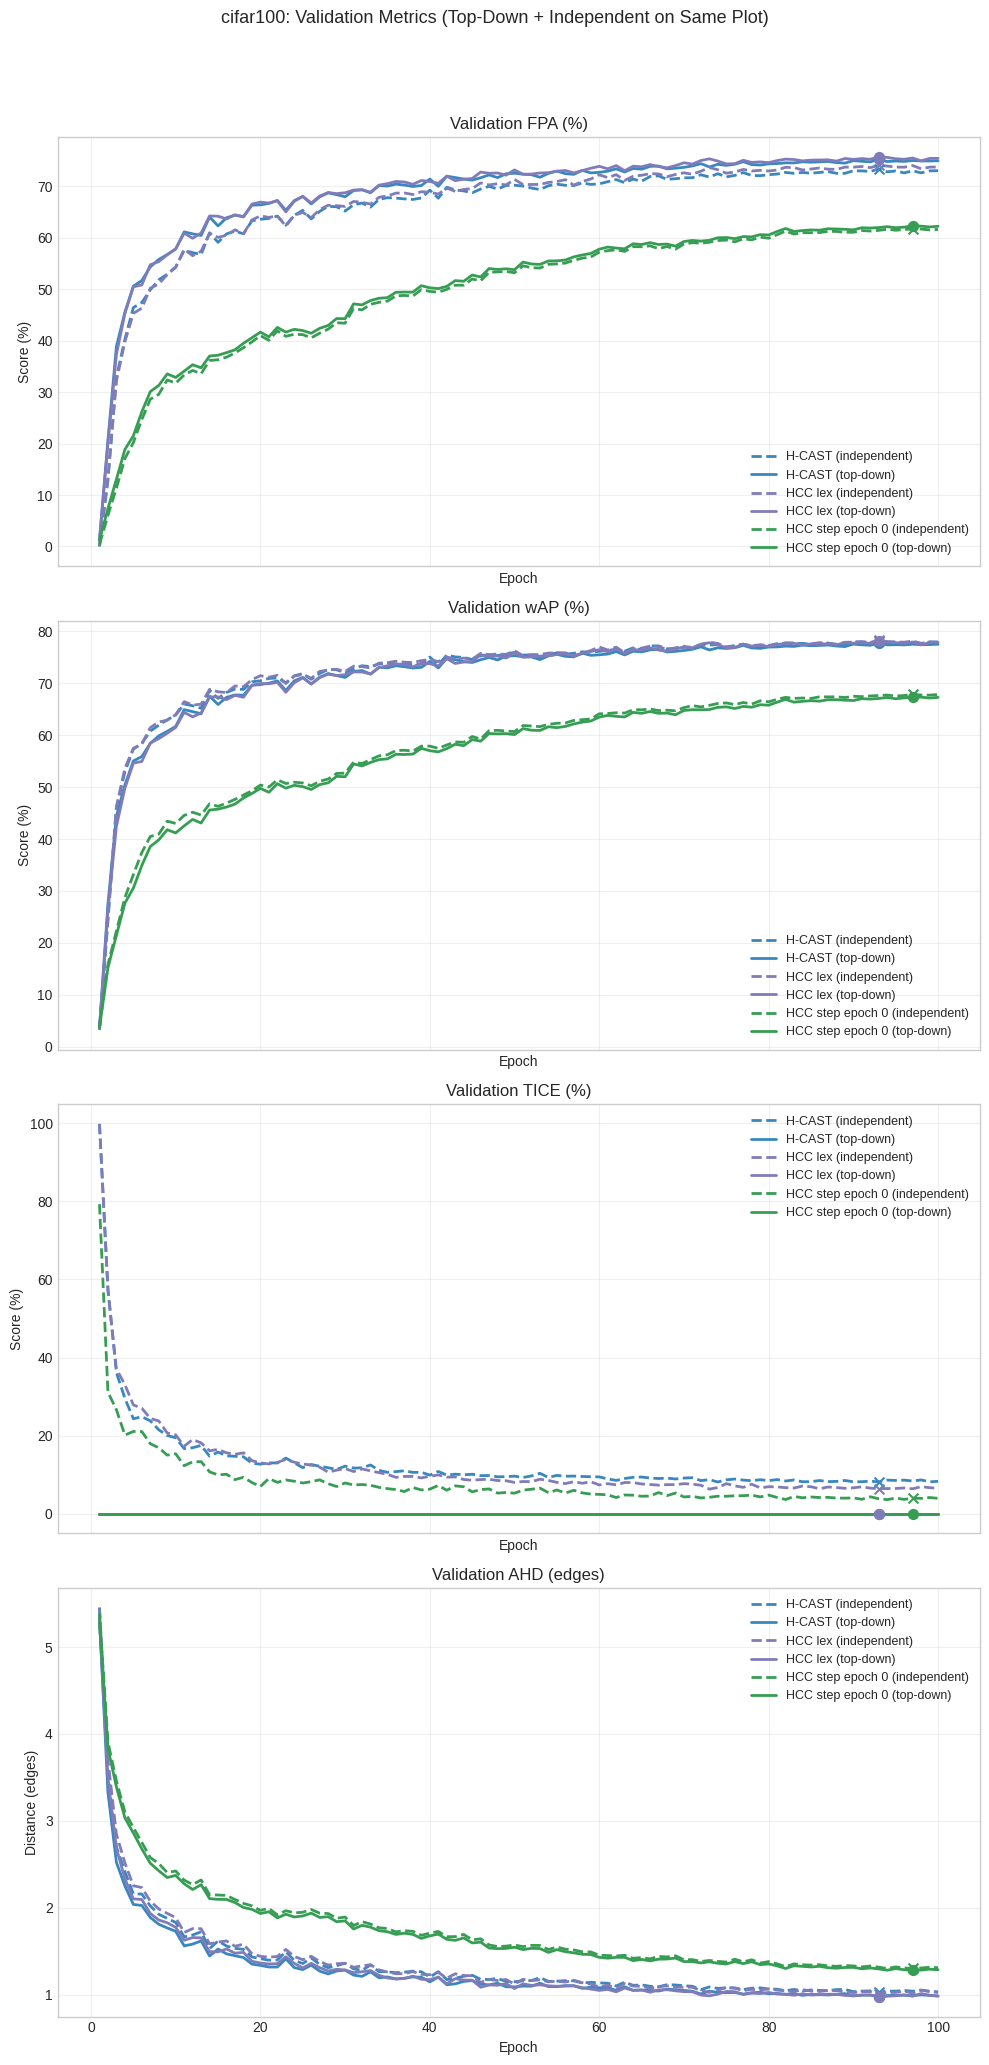

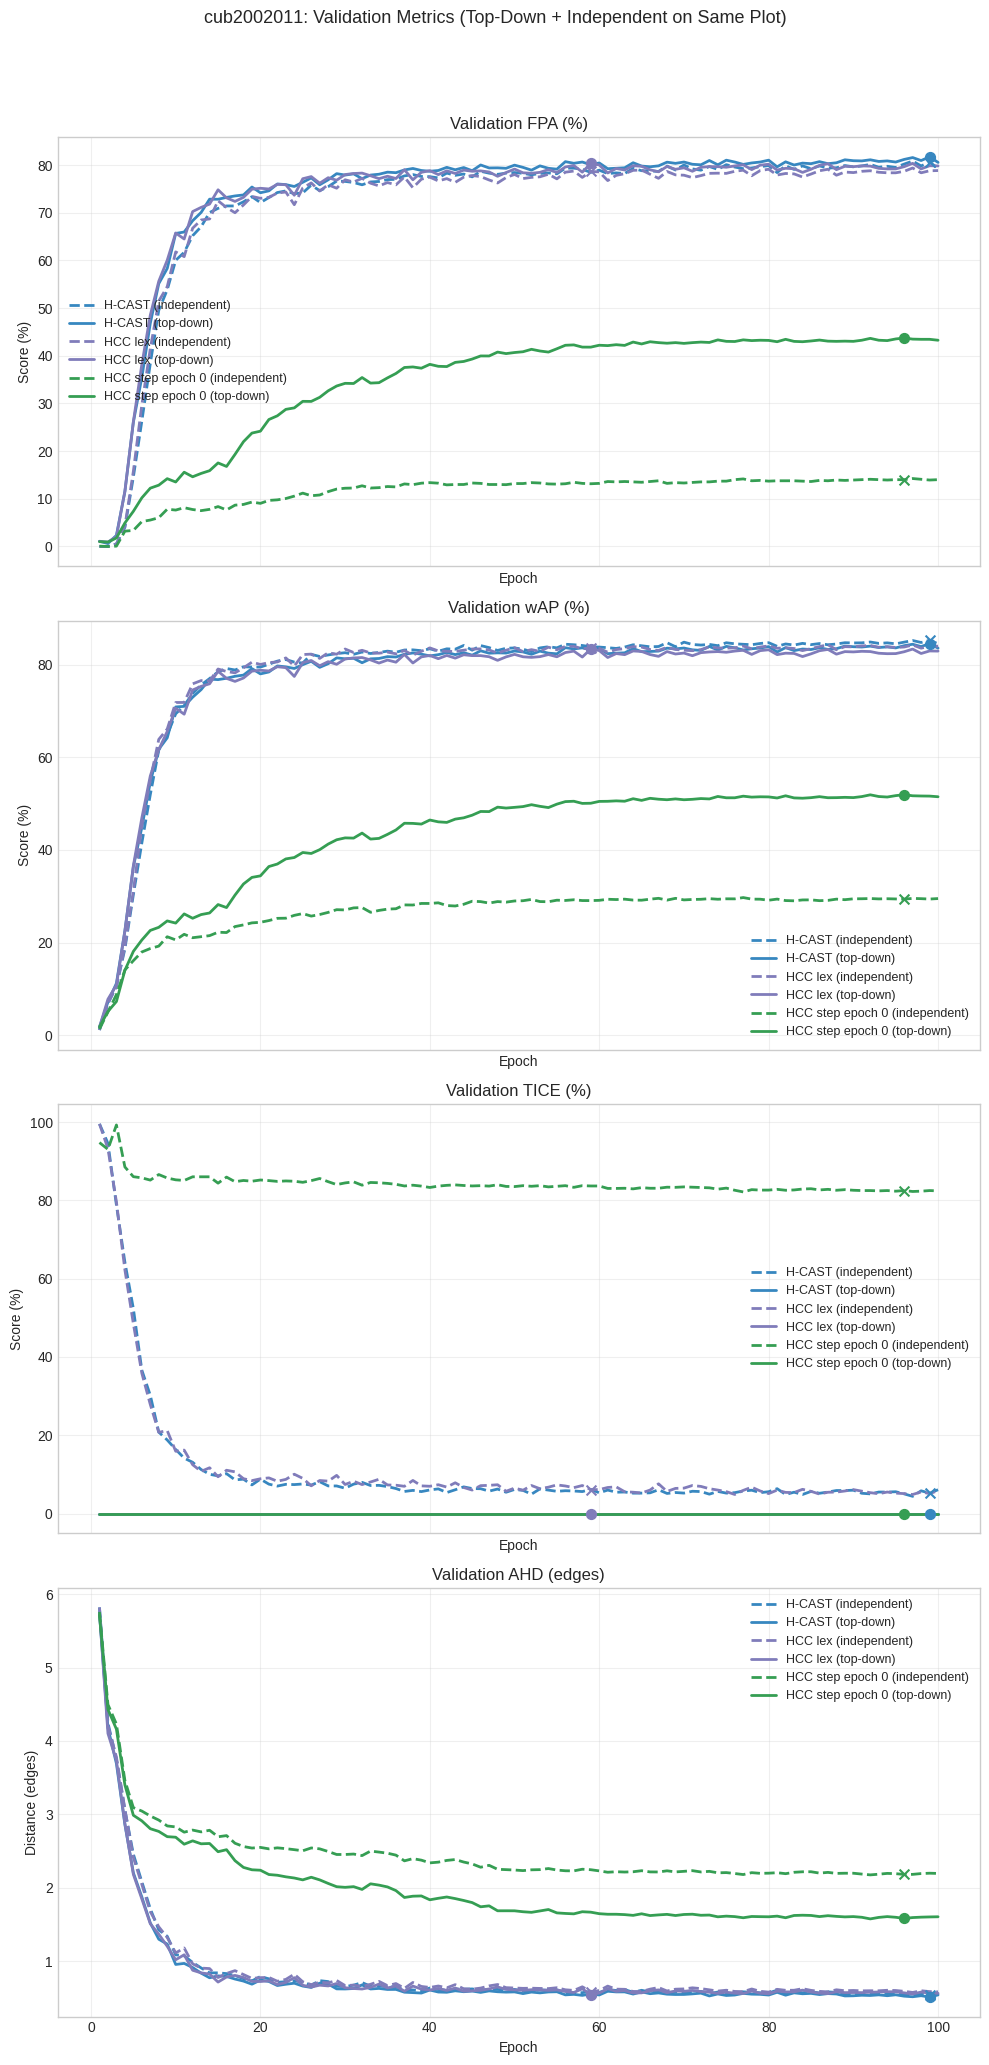

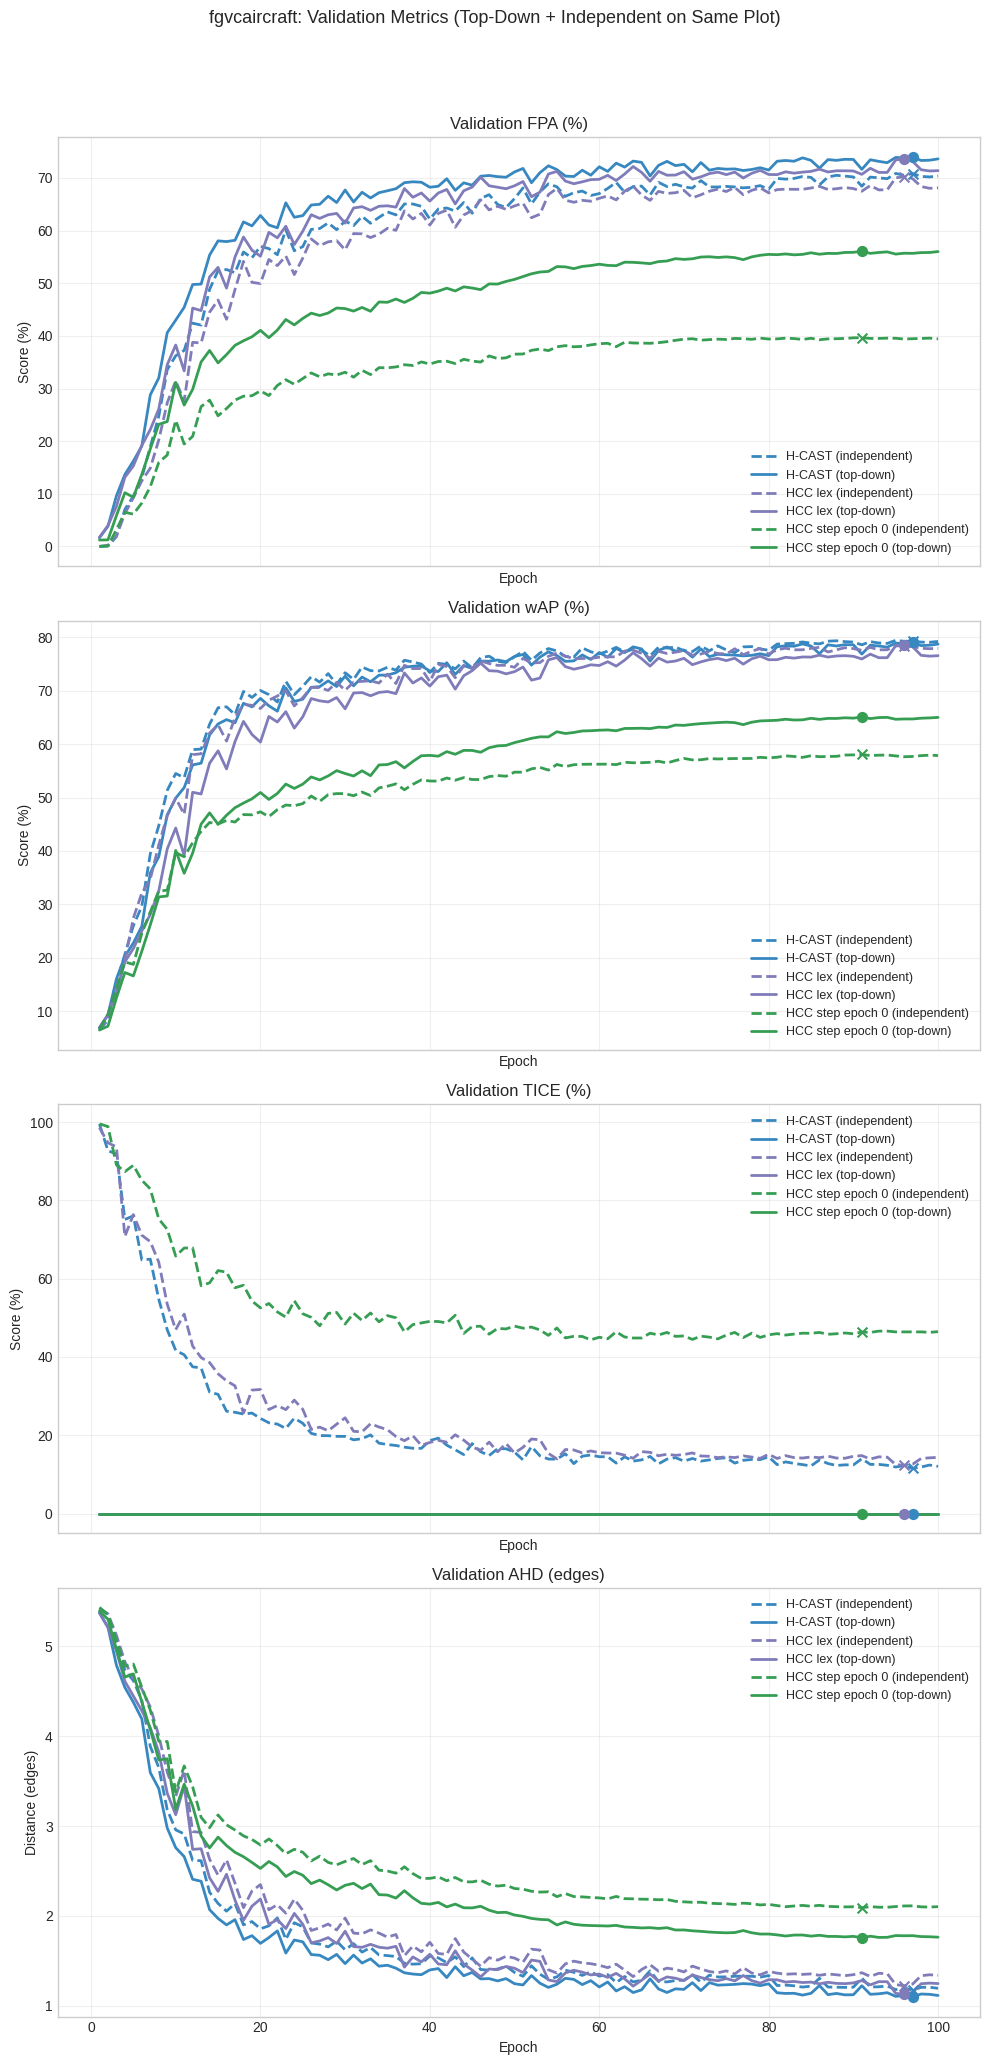

In [62]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (HCC)

This section visualizes projection diagnostics logged in `val_metrics` (when available):
- `proj_constraint_alpha` (annealing blend/schedule value),
- `proj_constraint_strength` (intrinsic projection strength),
- `proj_temperature`,
- `proj_mode_intrinsic_soft`,
- `proj_has_negative` and per-level `proj_neg_frac_level_*`.


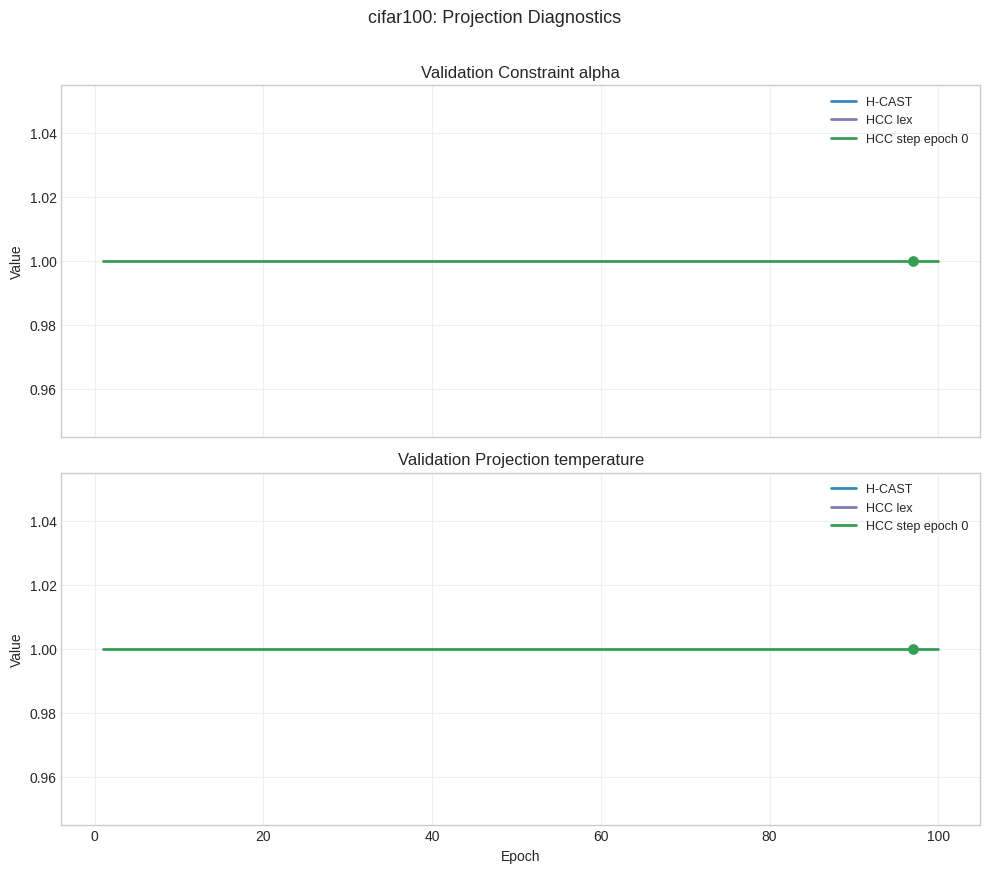

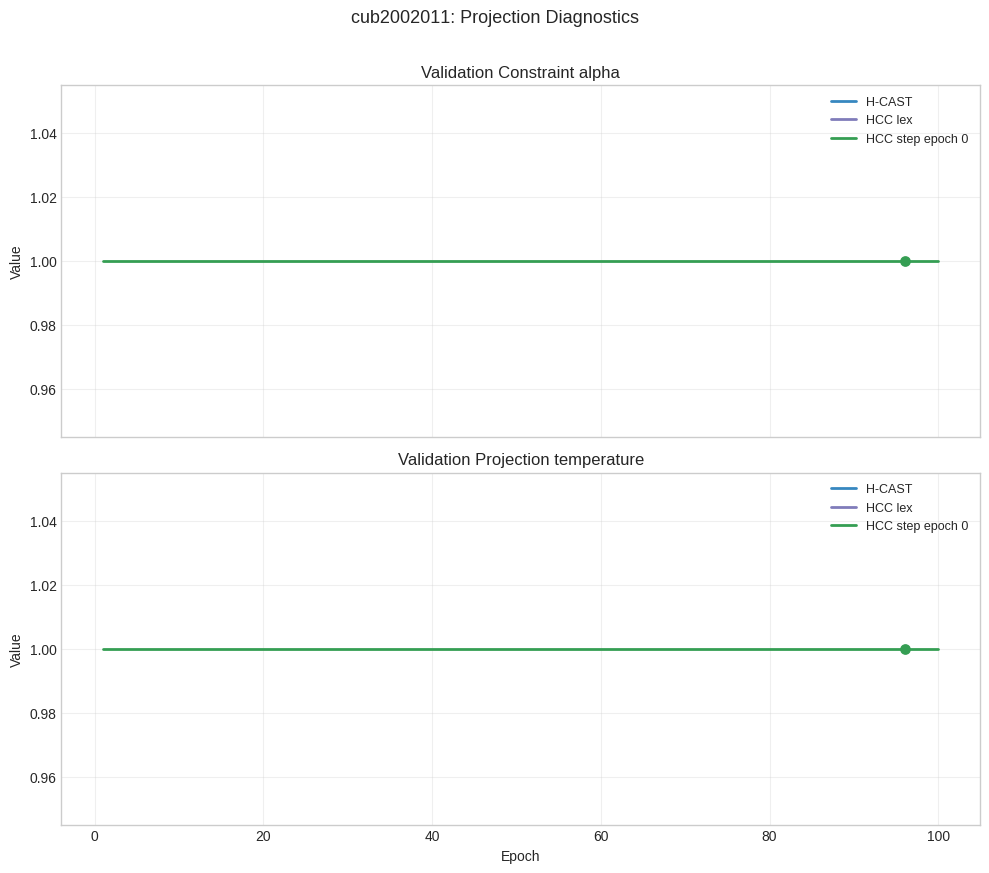

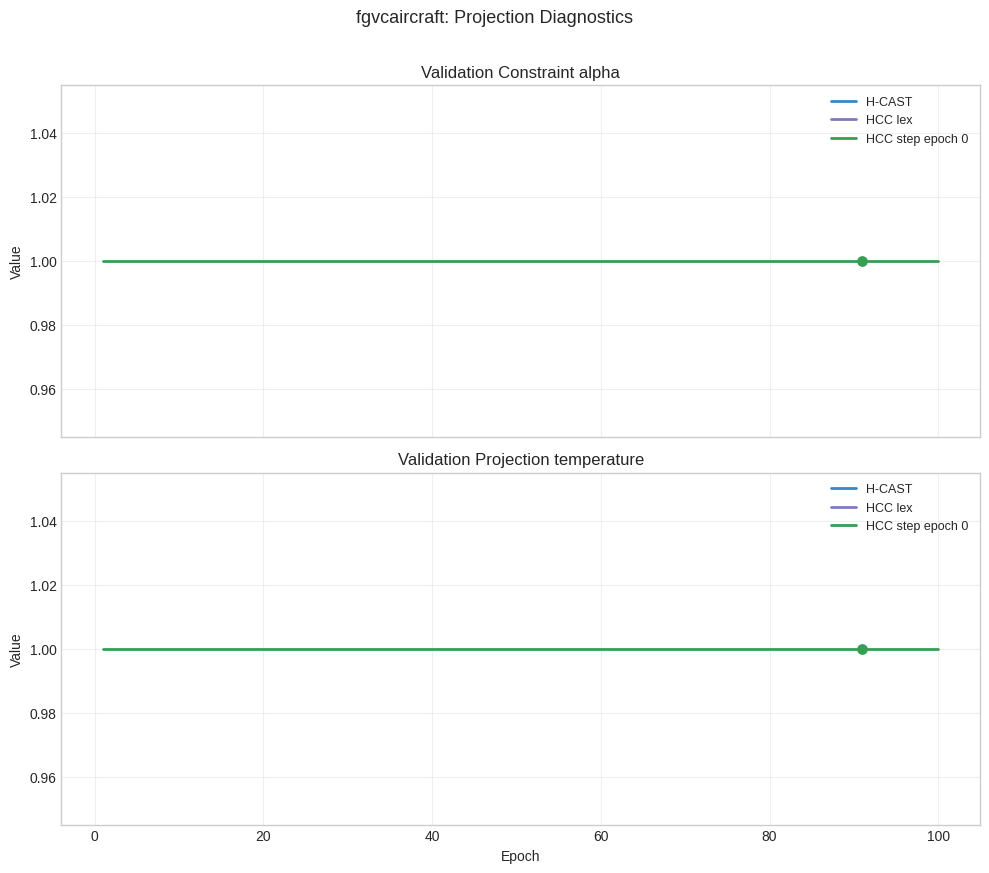

In [63]:
analysis.plot_projection_diagnostics()


## Training Loss Comparison

This section compares training losses between runs for both aggregate losses (`total`, `level_ce`, `gk_loss`) and per-level losses (`loss_level_*`).

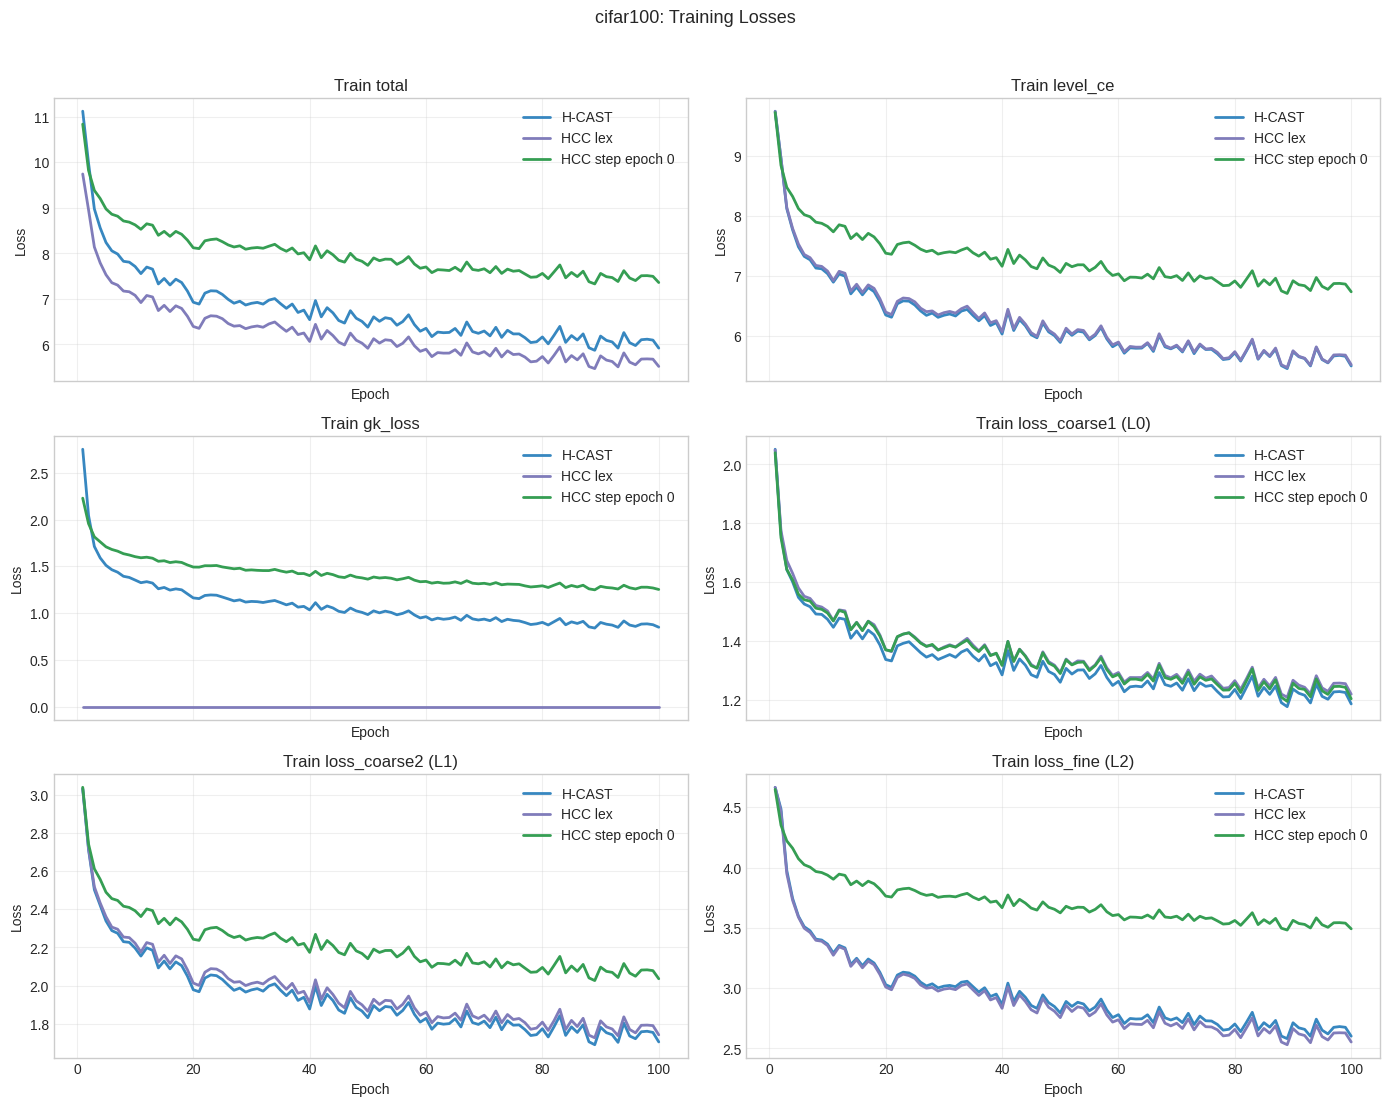

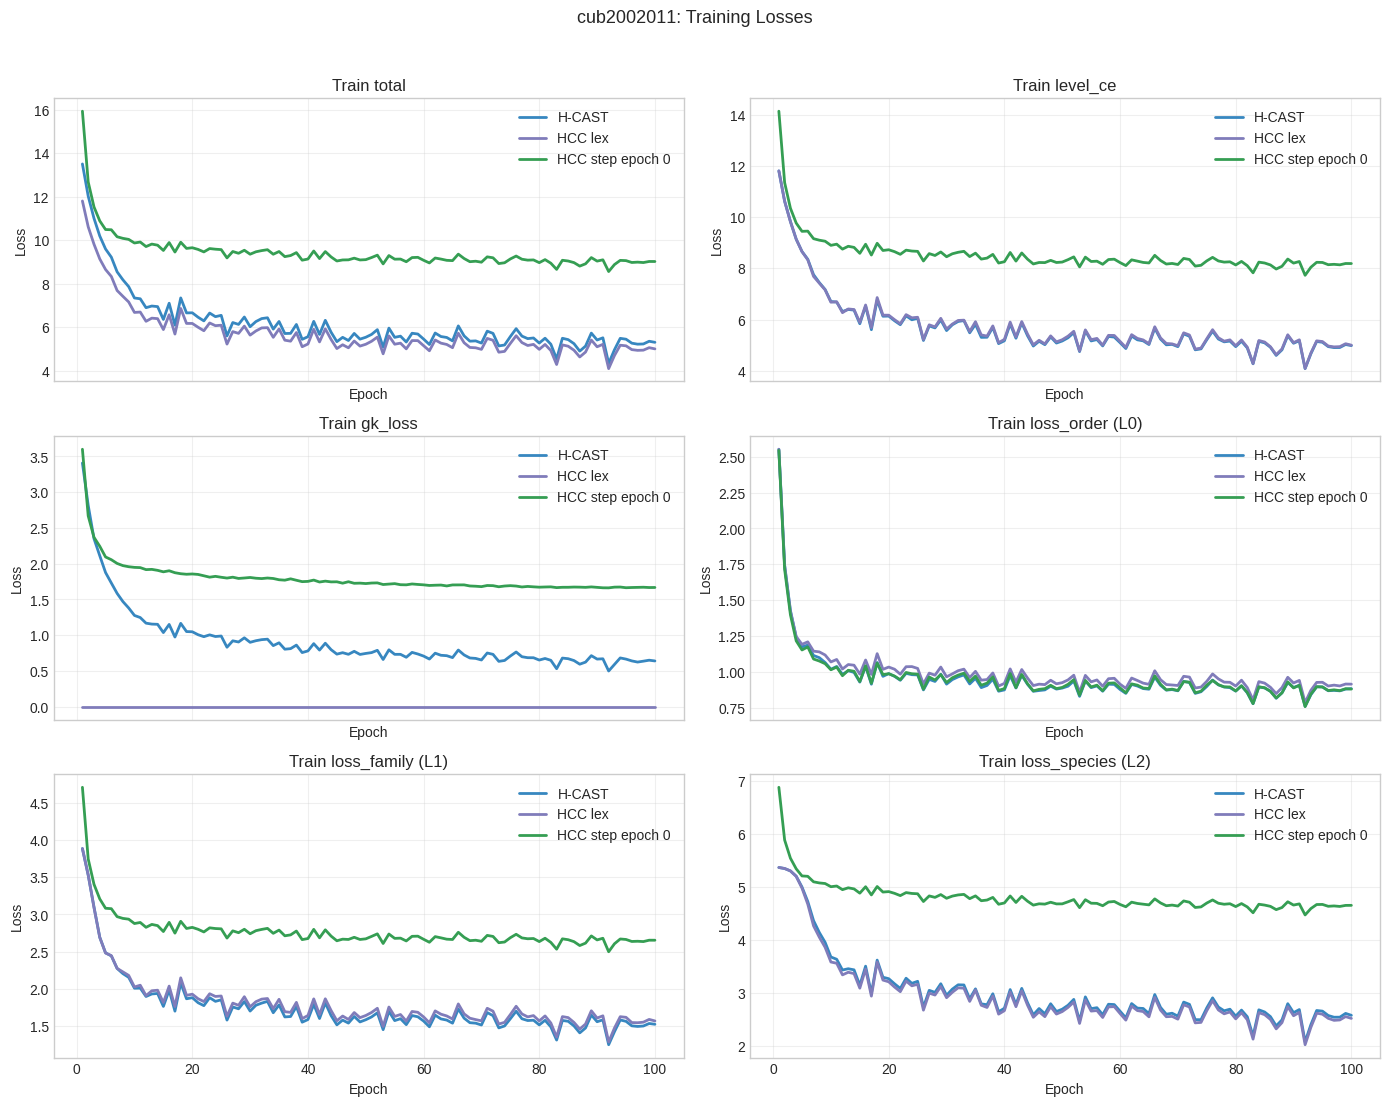

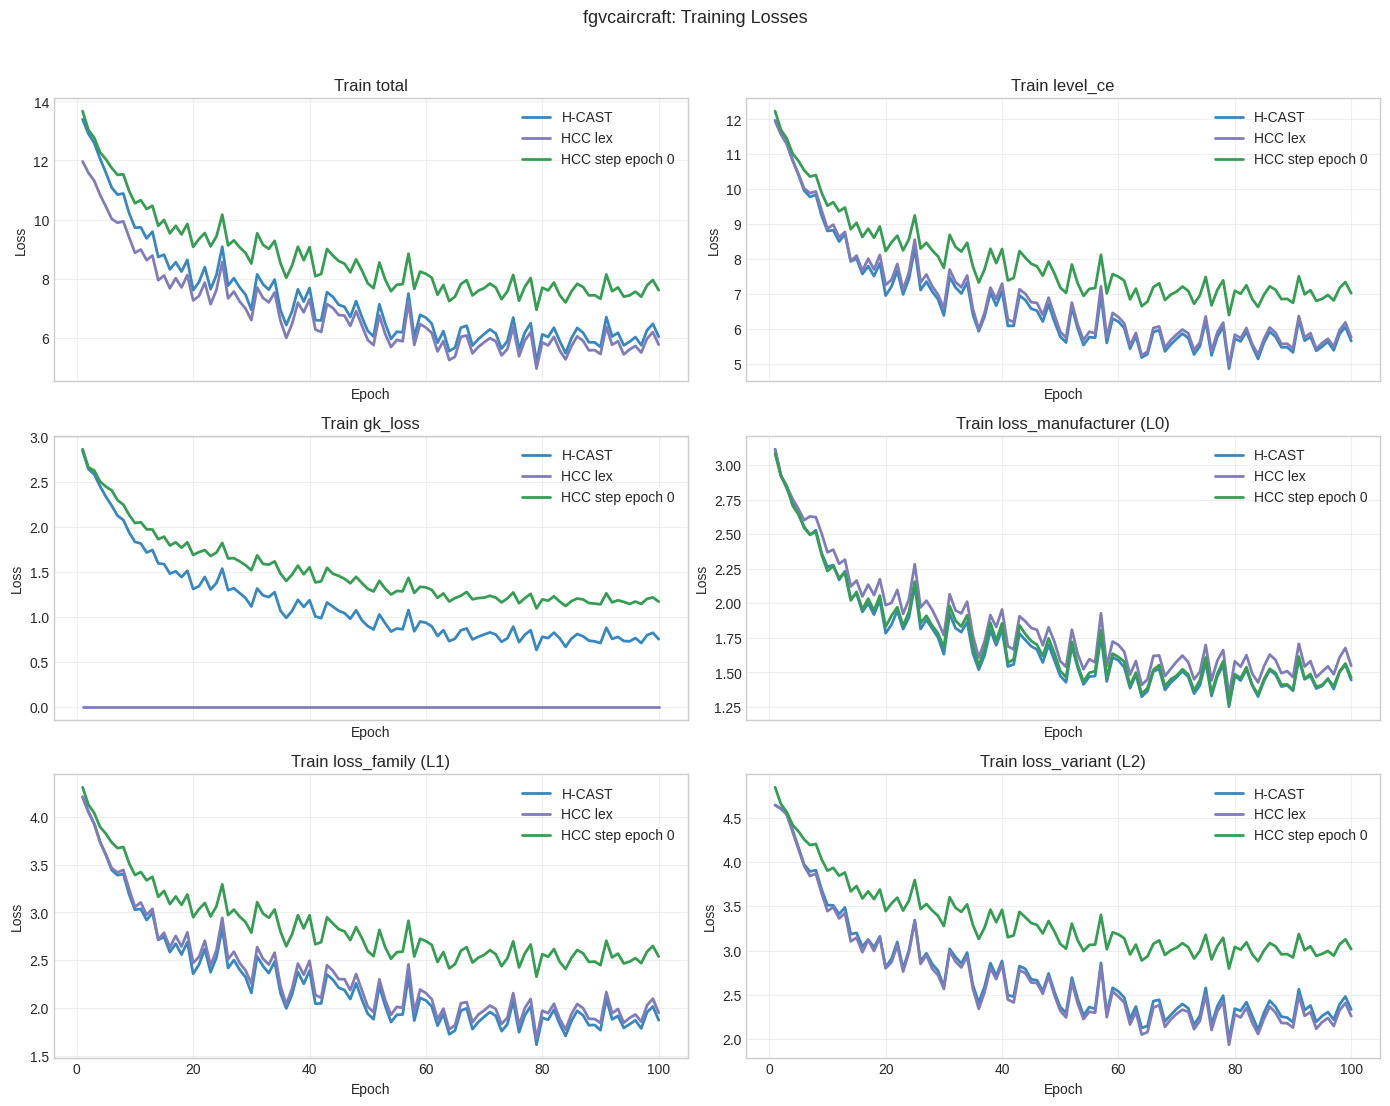

In [64]:
analysis.plot_training_losses()


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (Per Dataset)

Interpretation note:
- Each chart corresponds to one selected run in its dataset section.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



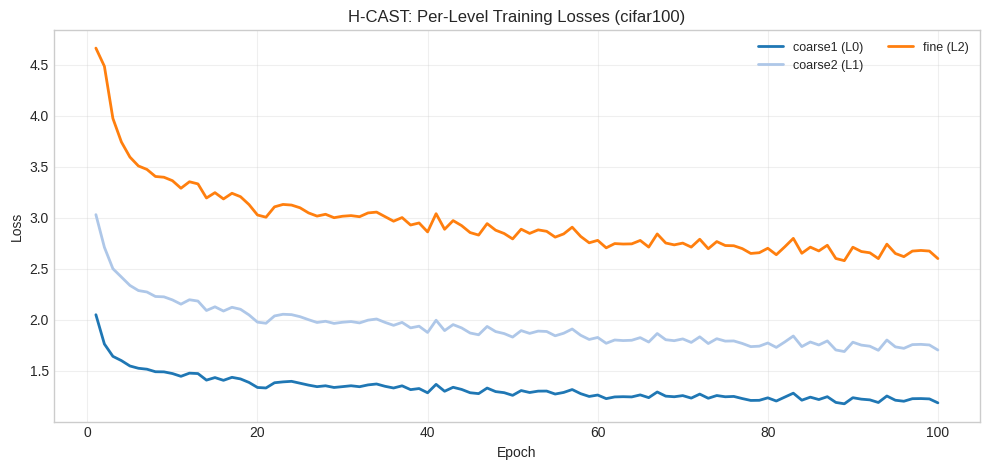

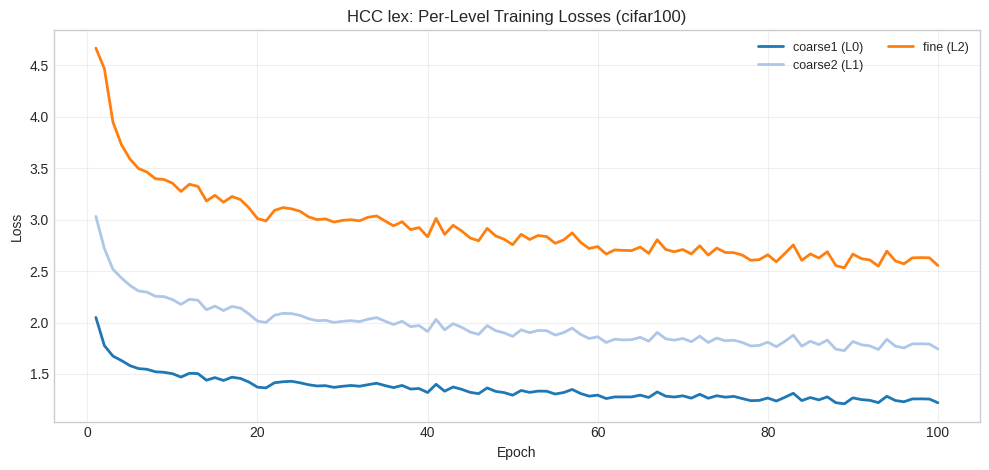

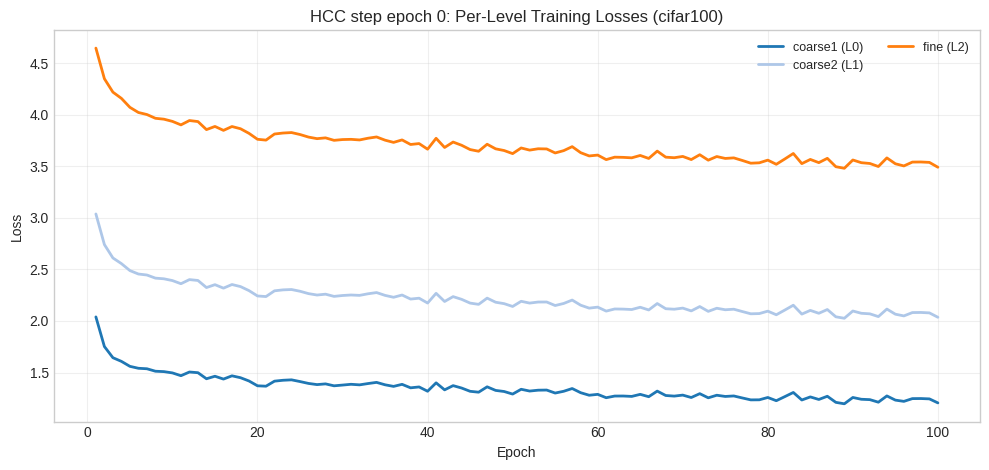

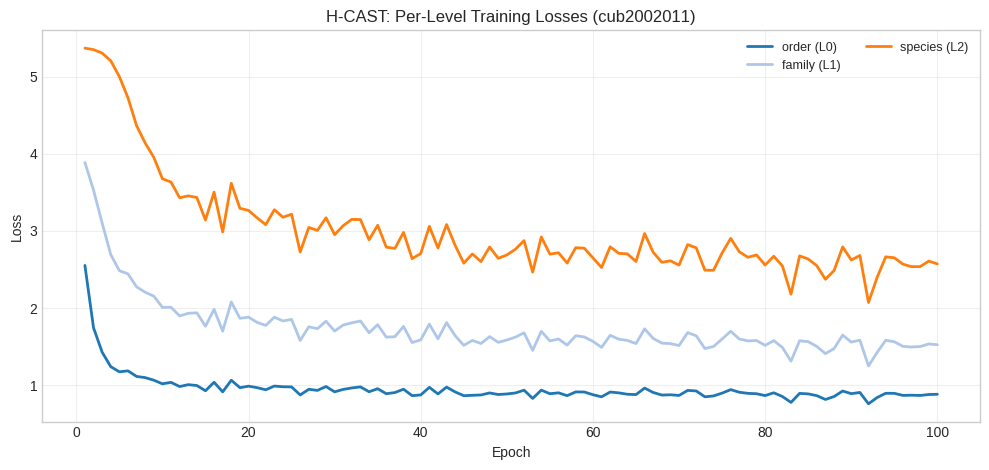

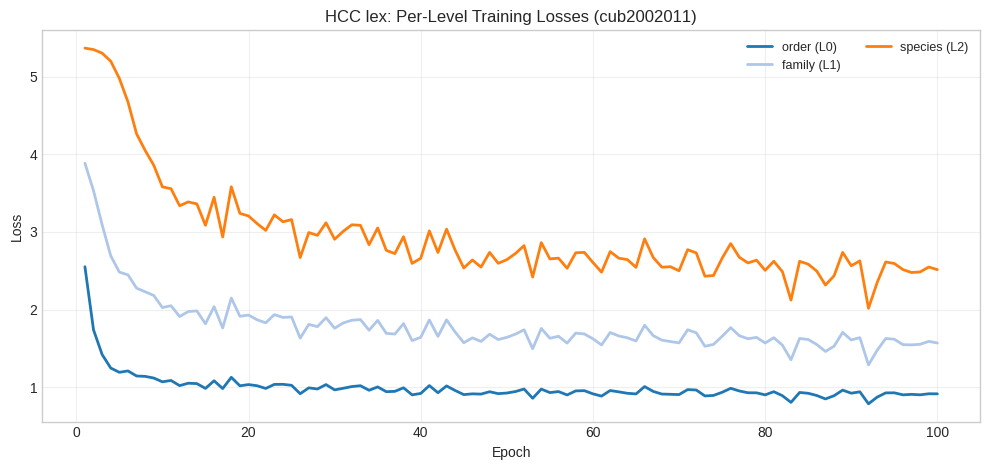

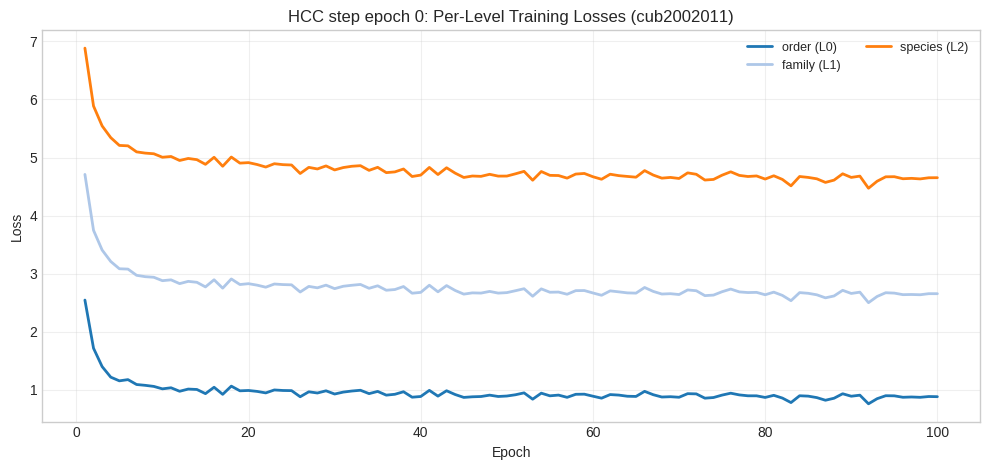

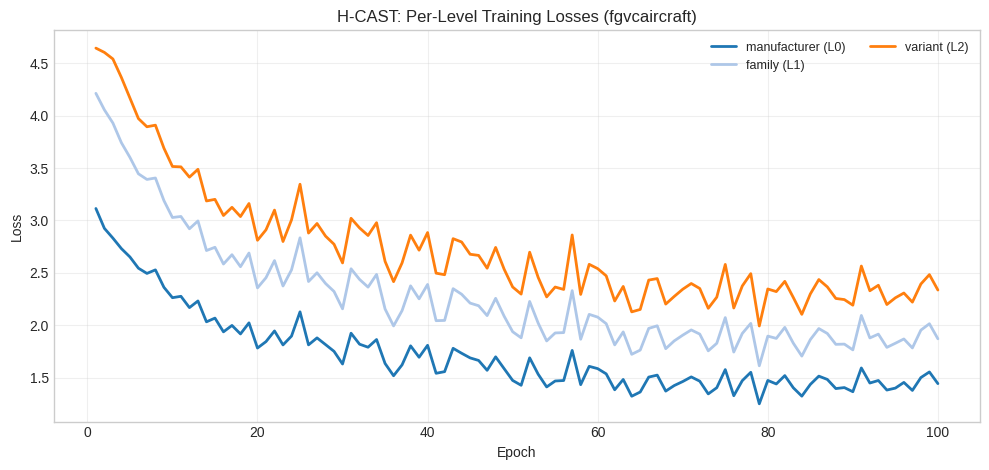

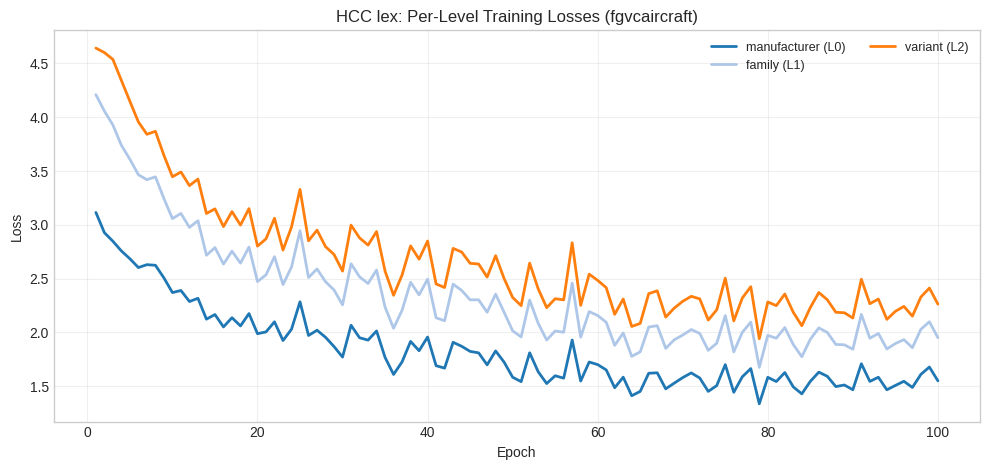

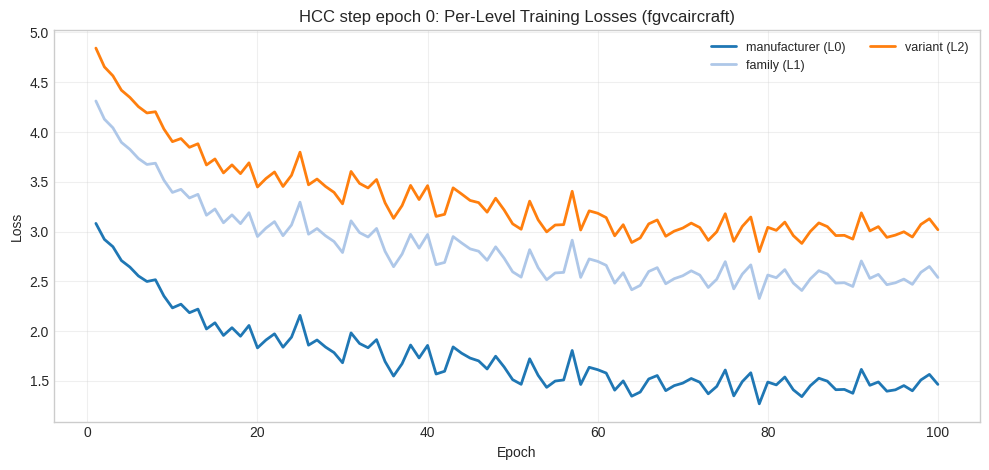

In [65]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and lexicographic projection diagnostics stored in `train_metrics` for each epoch.

- Standard views are organized by subsets: `t3t2t1`, `t3`, `t2t1`, `t2`, and `t1`.
- Pre-gradient norms include:
  - `t3t2t1`: coarse
  - `t3`: coarse
  - `t2t1`: coarse, mid
  - `t2`: coarse, mid
  - `t1`: coarse, mid, fine
- Gradient cosines shown: `cos_mid_coarse`, `cos_fine_coarse`, `cos_fine_mid` (pairwise, trunk-agnostic overlaps).
- Parameter norms/movement are shown on the same trunk subsets (`t3t2t1/t3/t2t1/t2/t1`).
- In lex mode, `post_grad_*` mirrors pre-gradient keys and a dedicated pre-vs-post overlay is plotted.


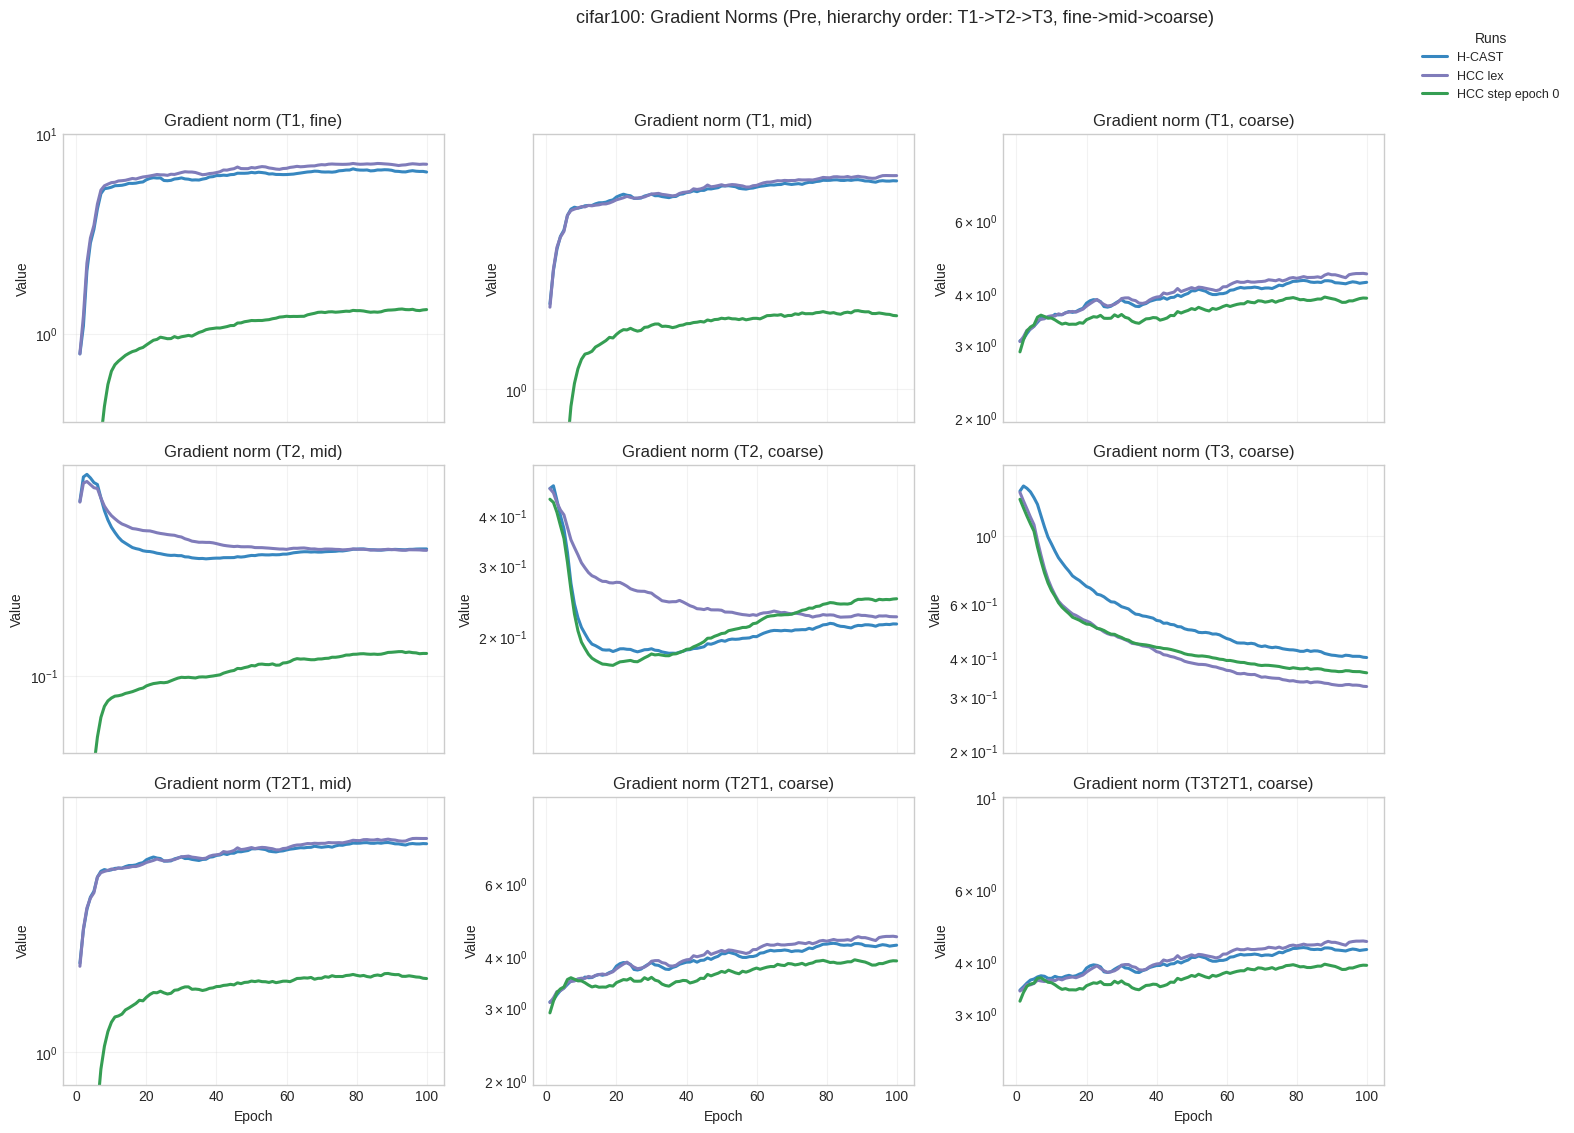

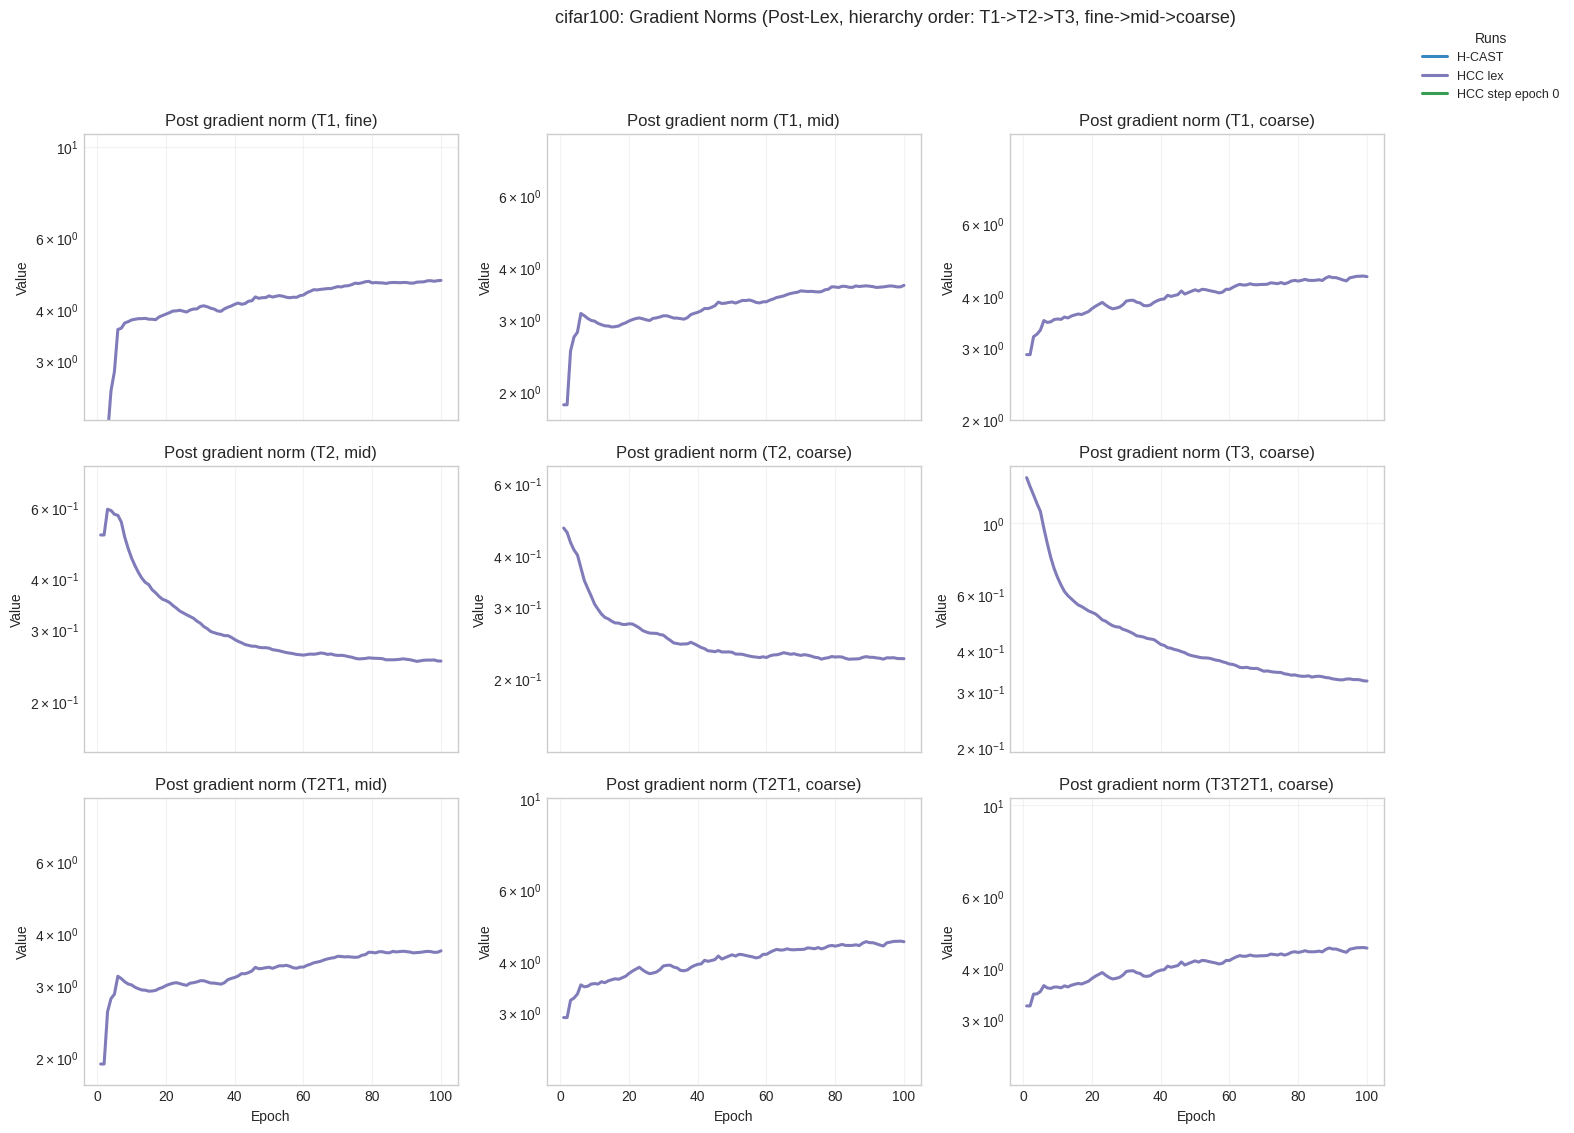

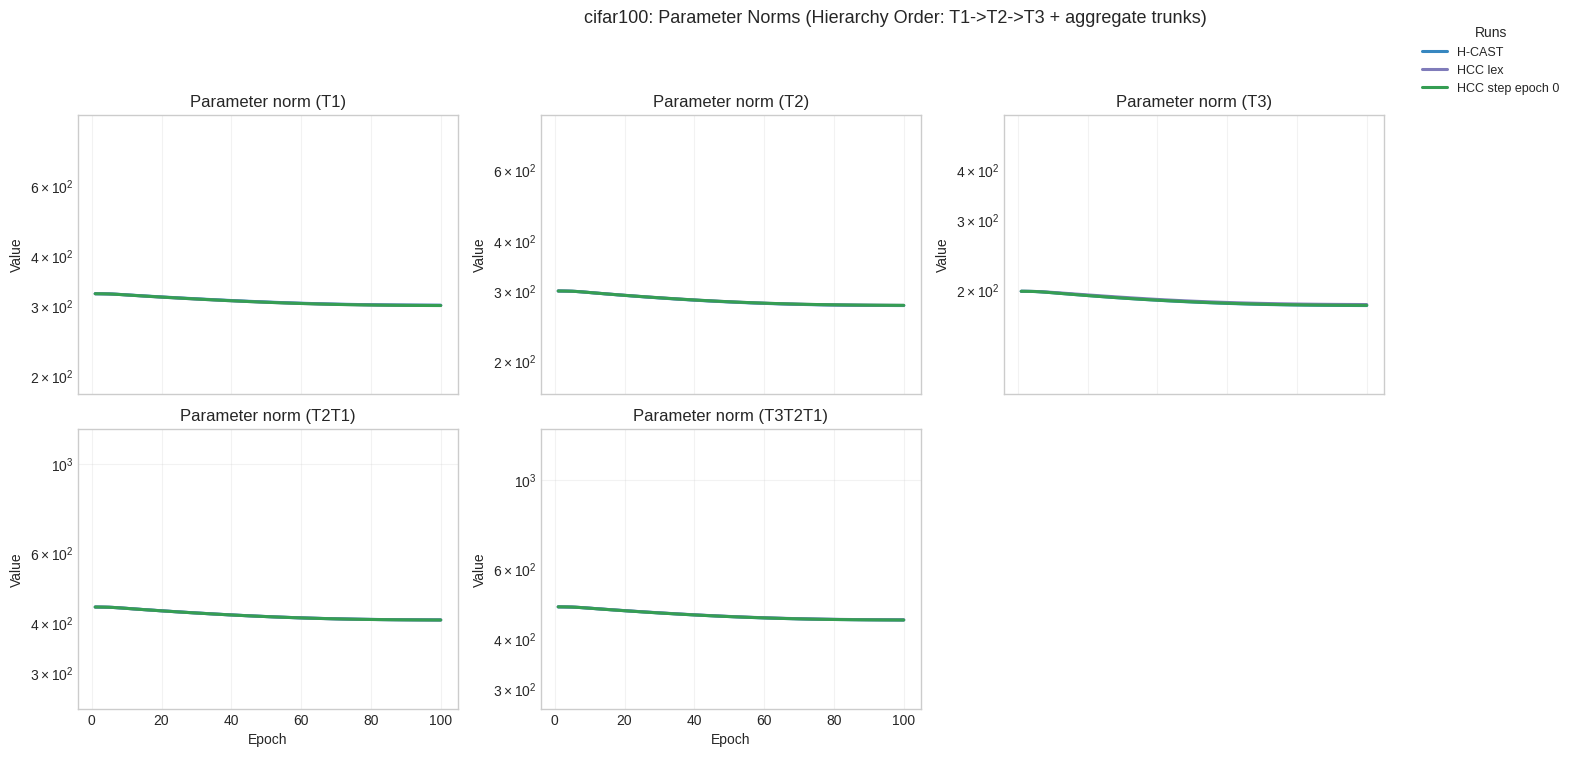

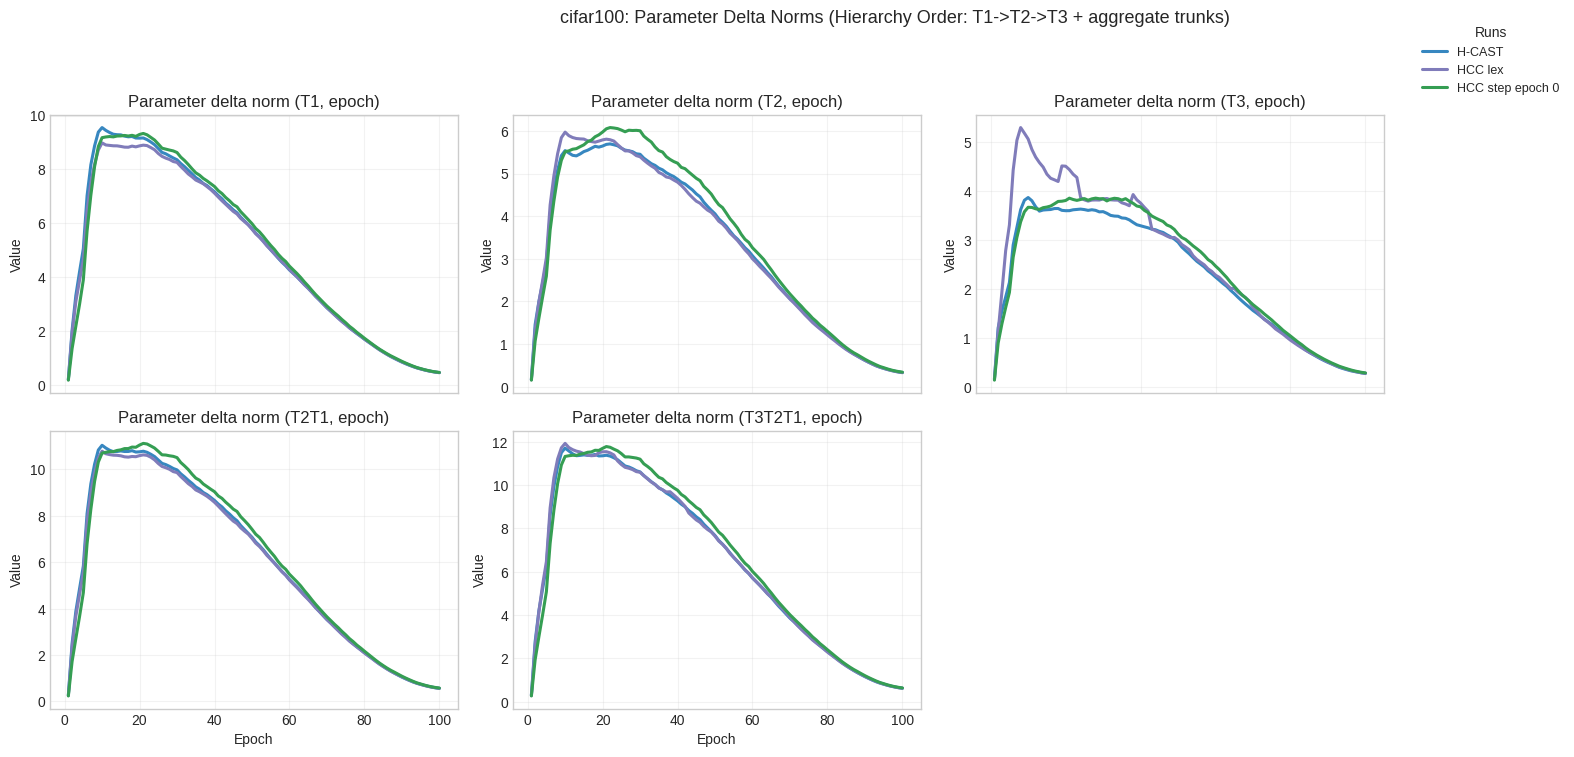

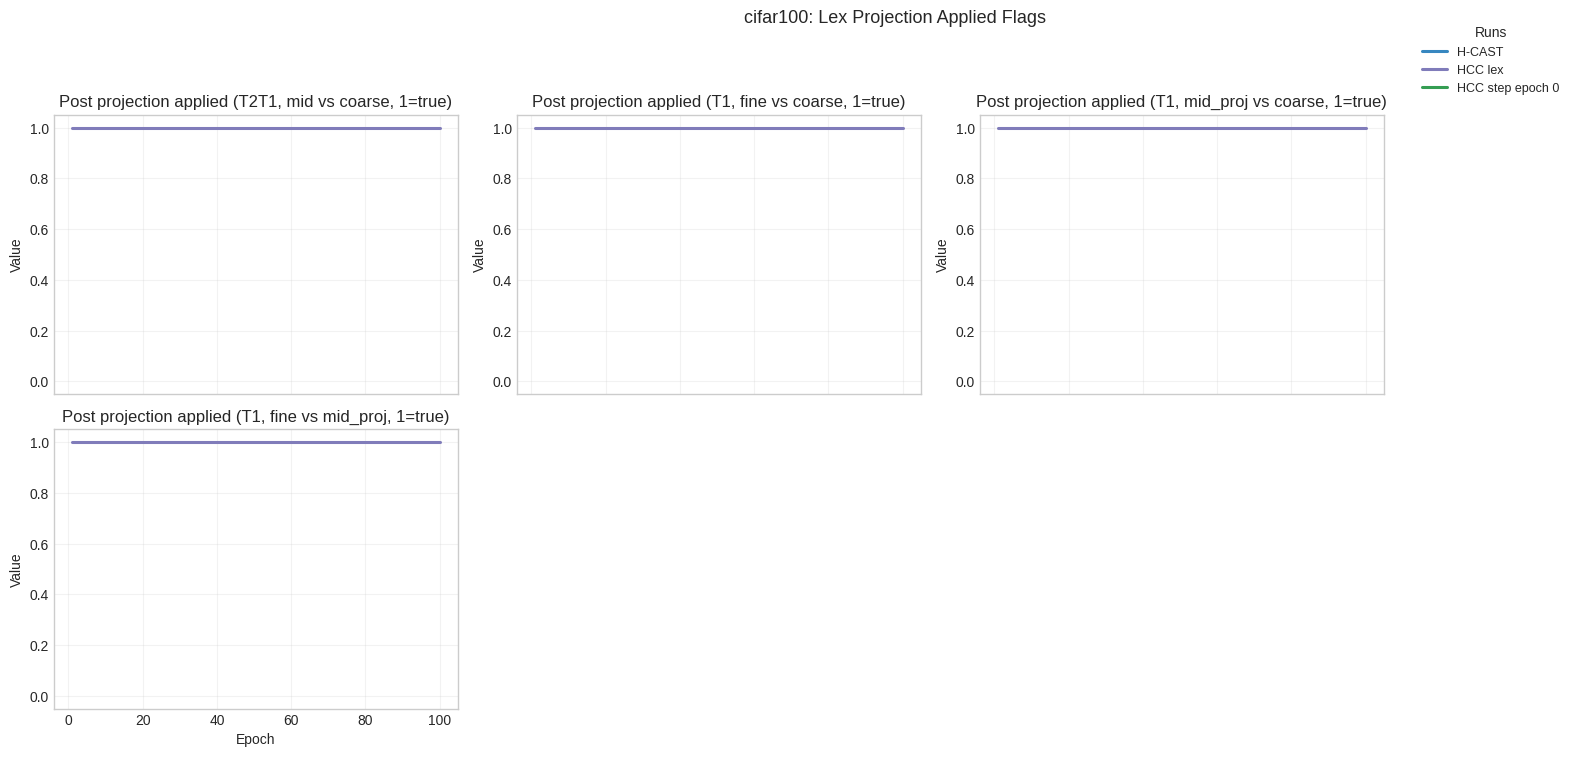

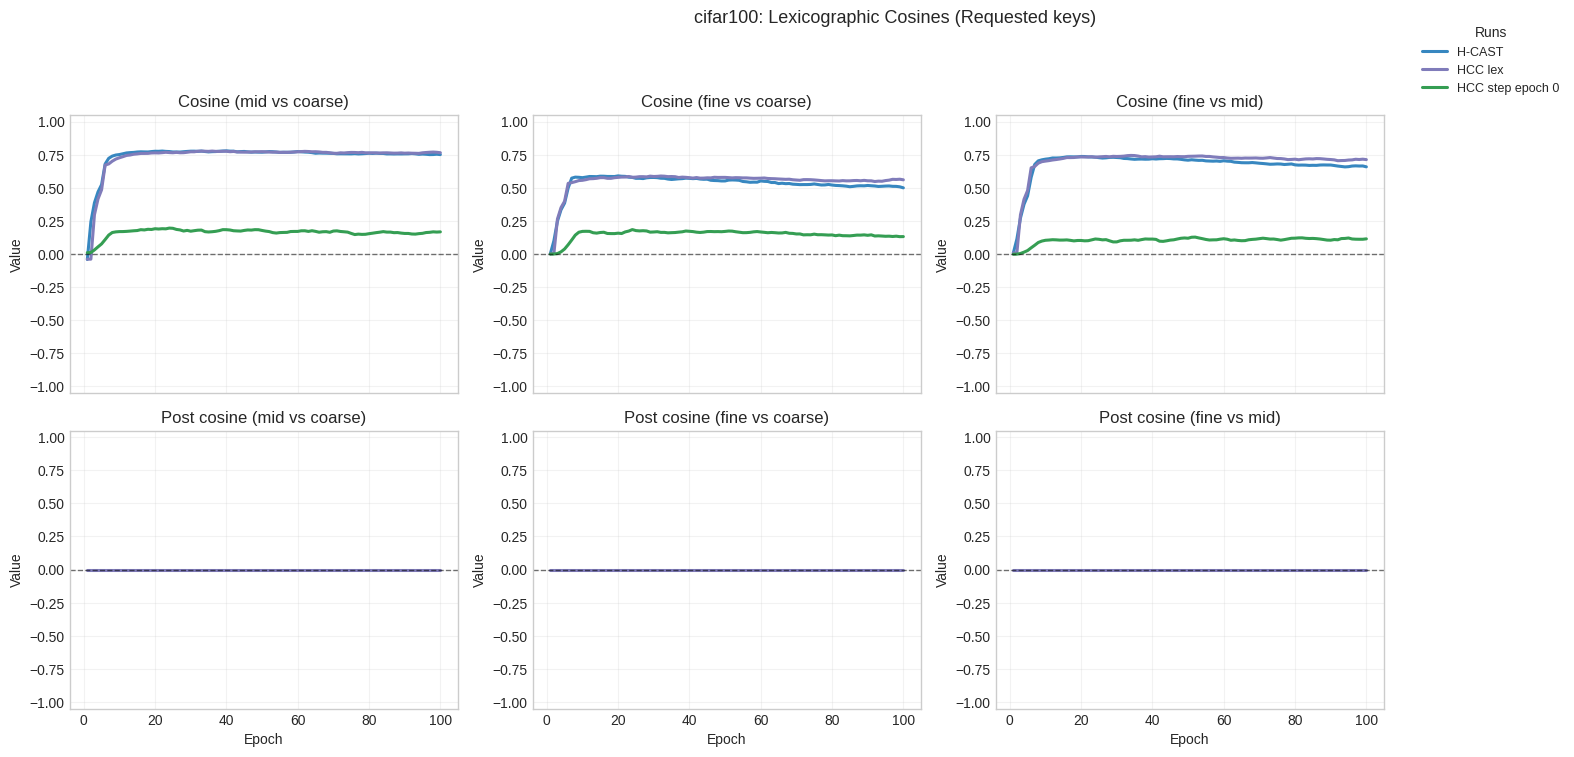

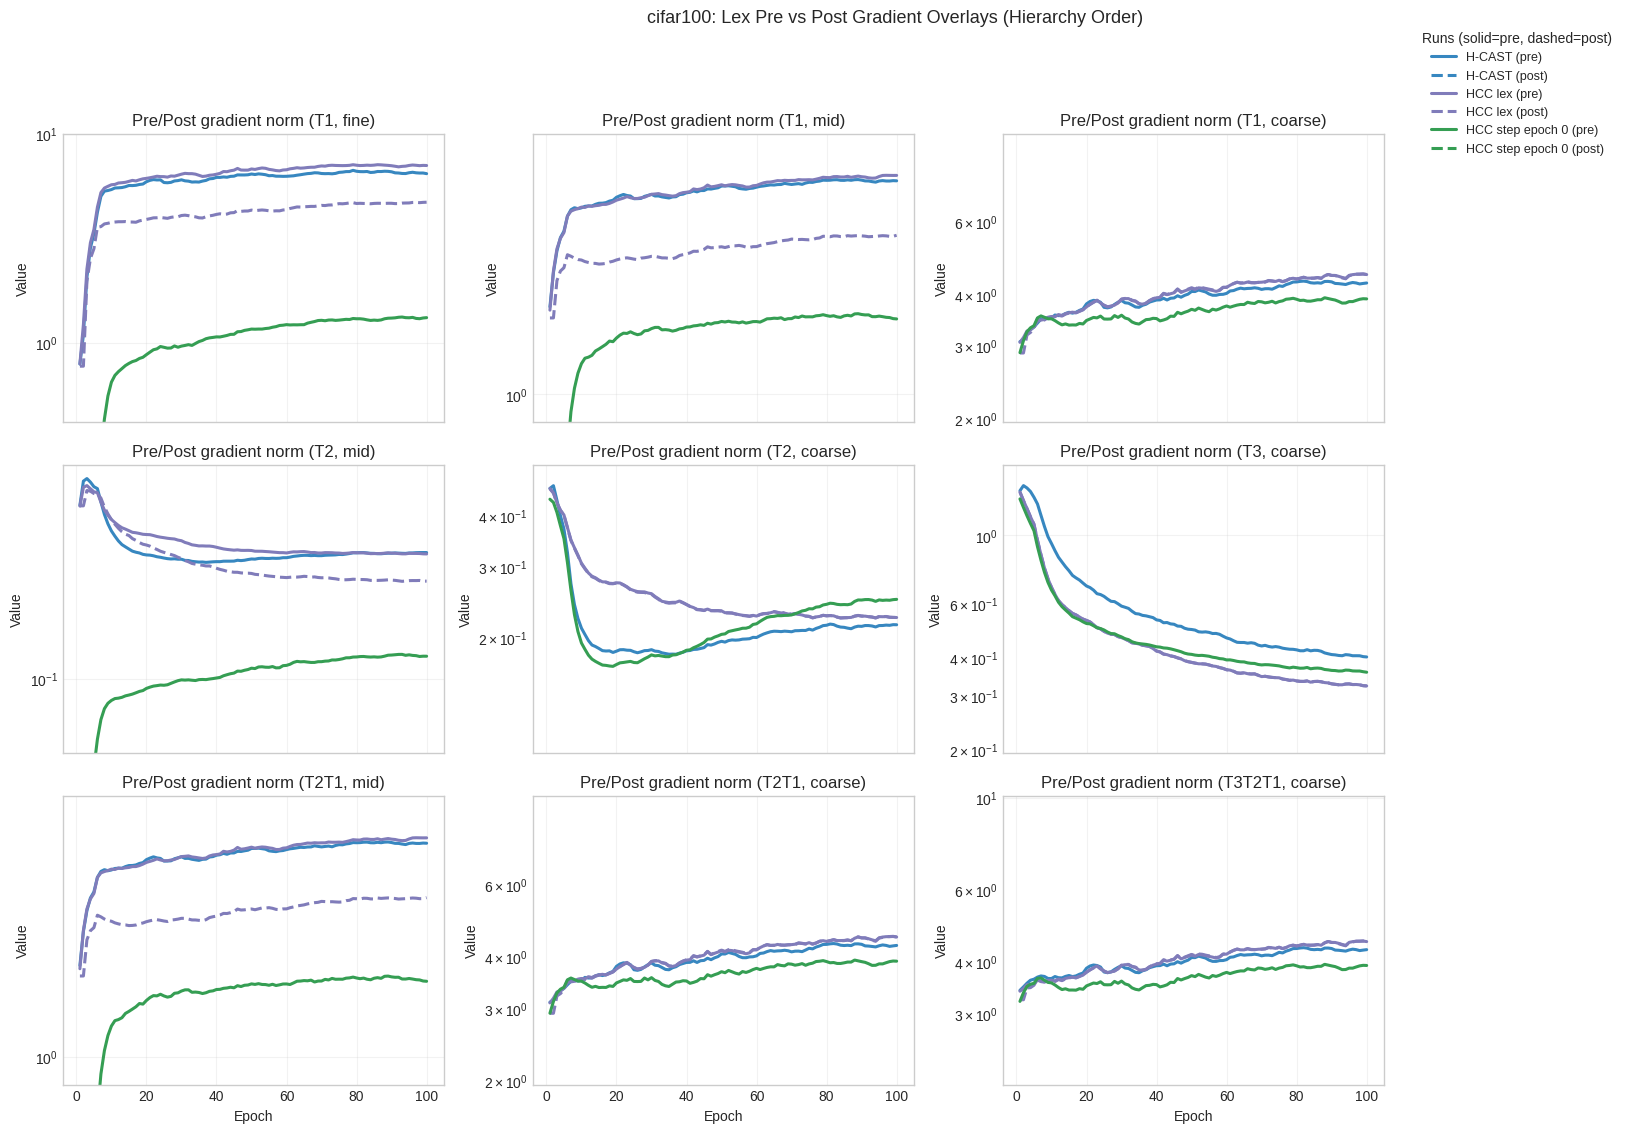

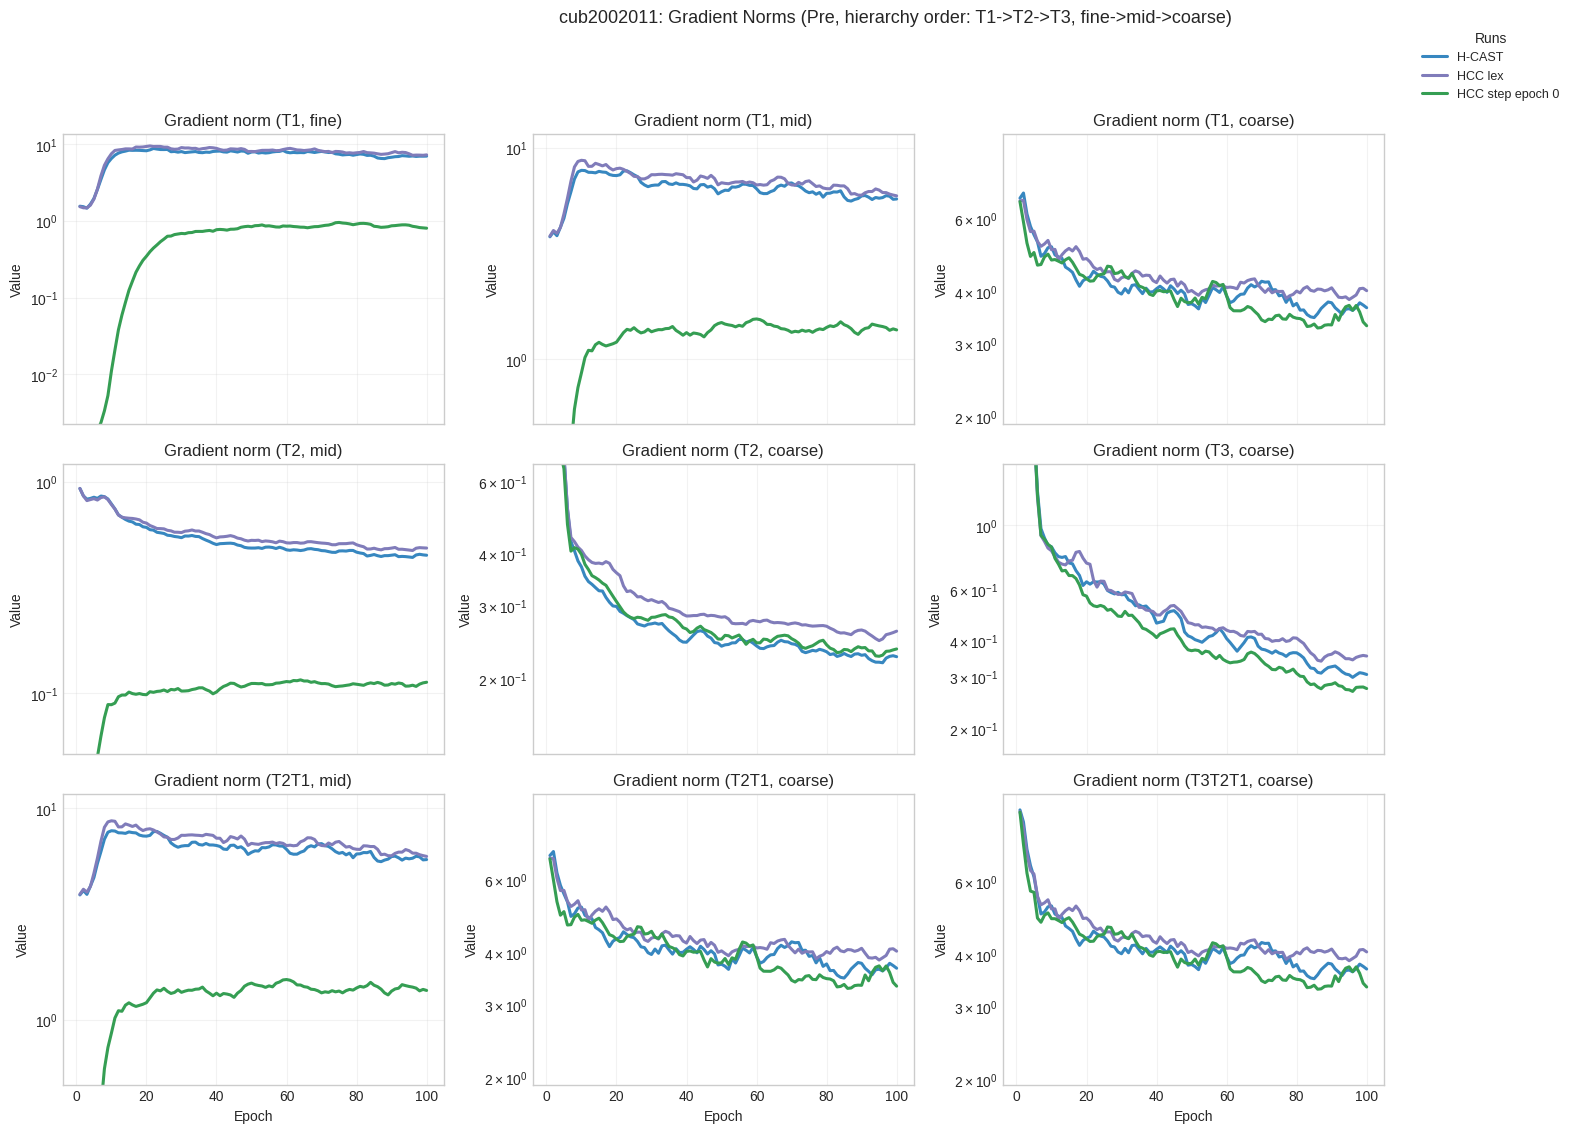

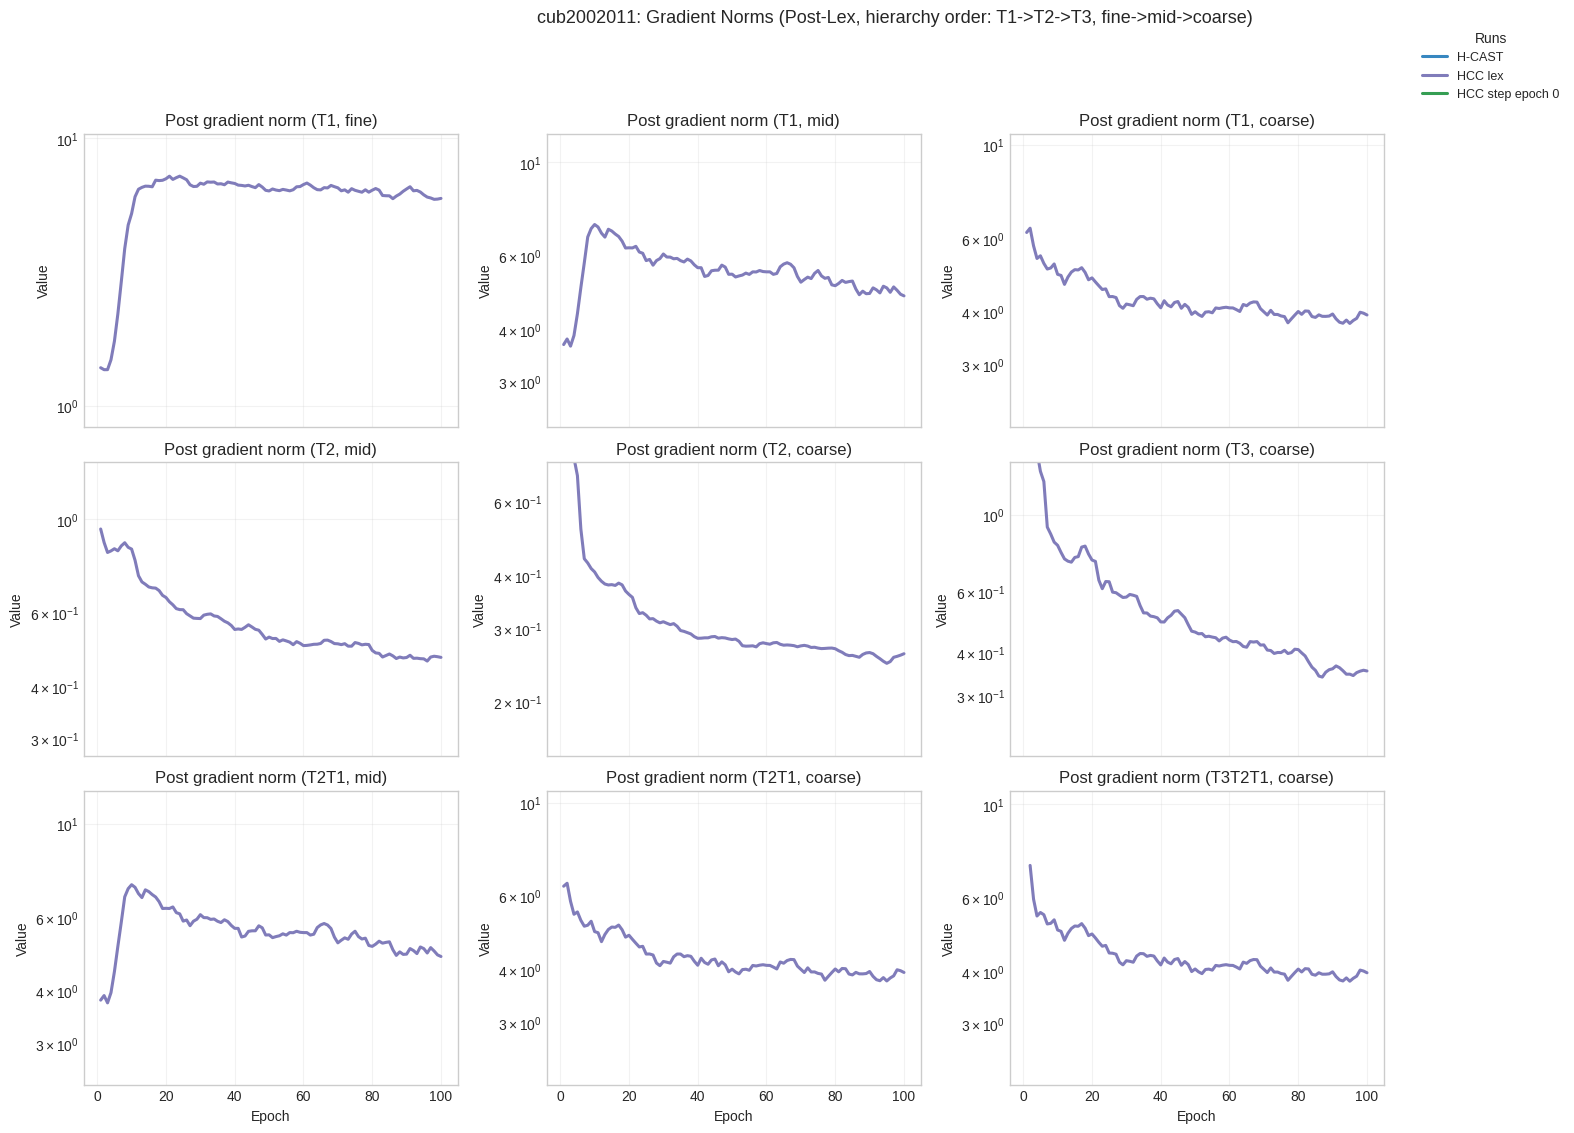

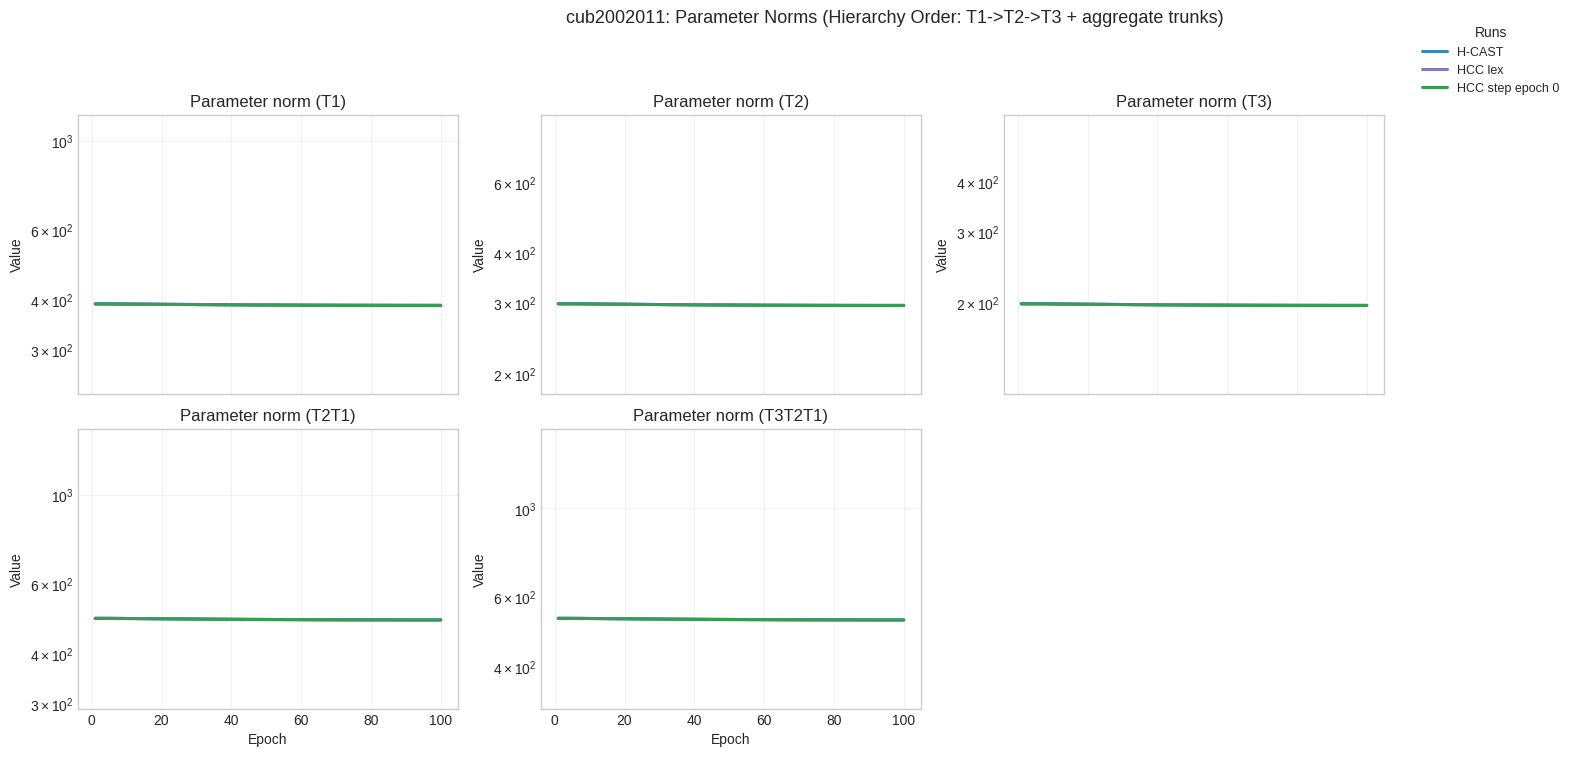

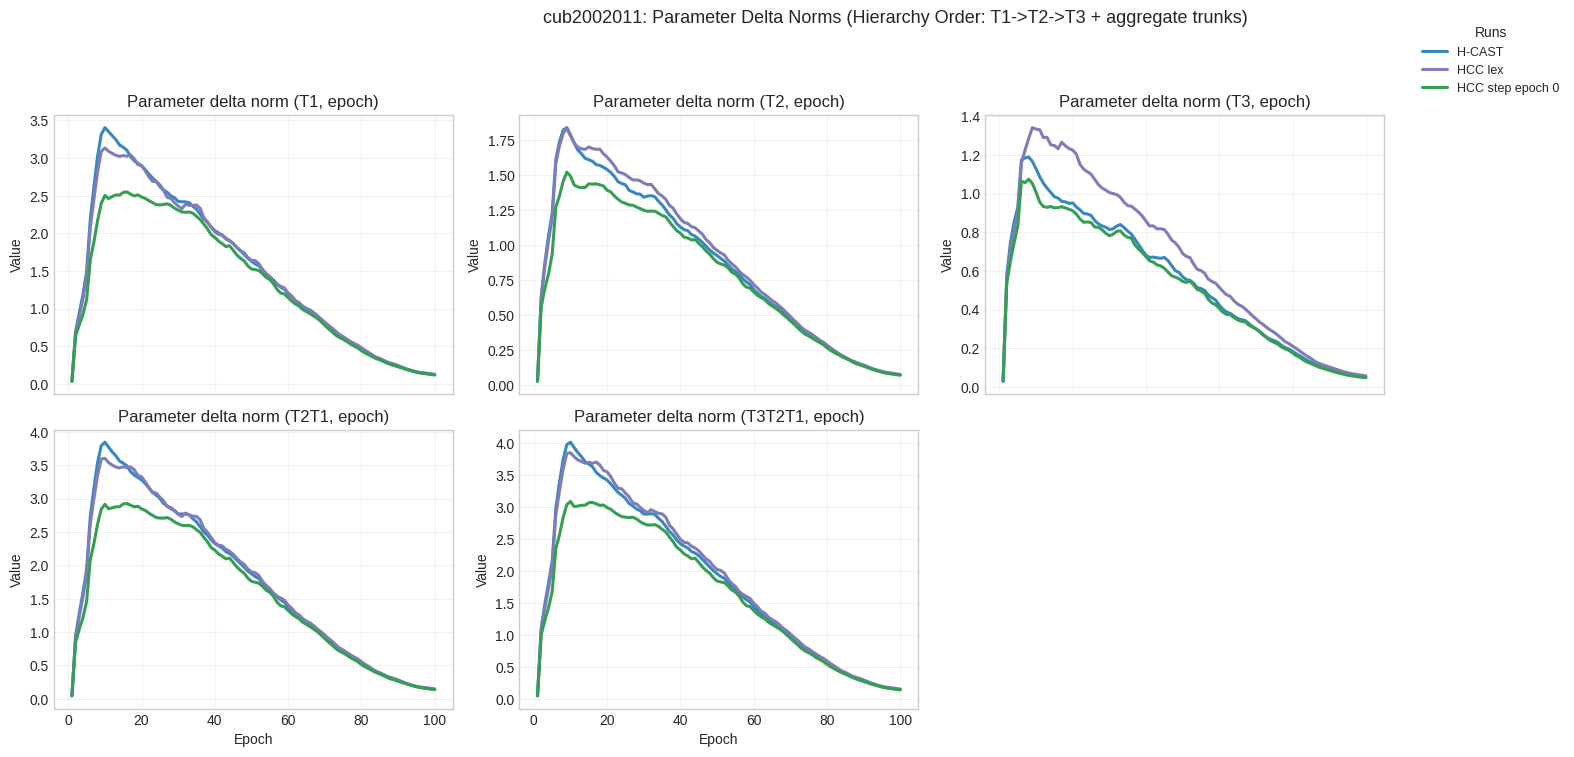

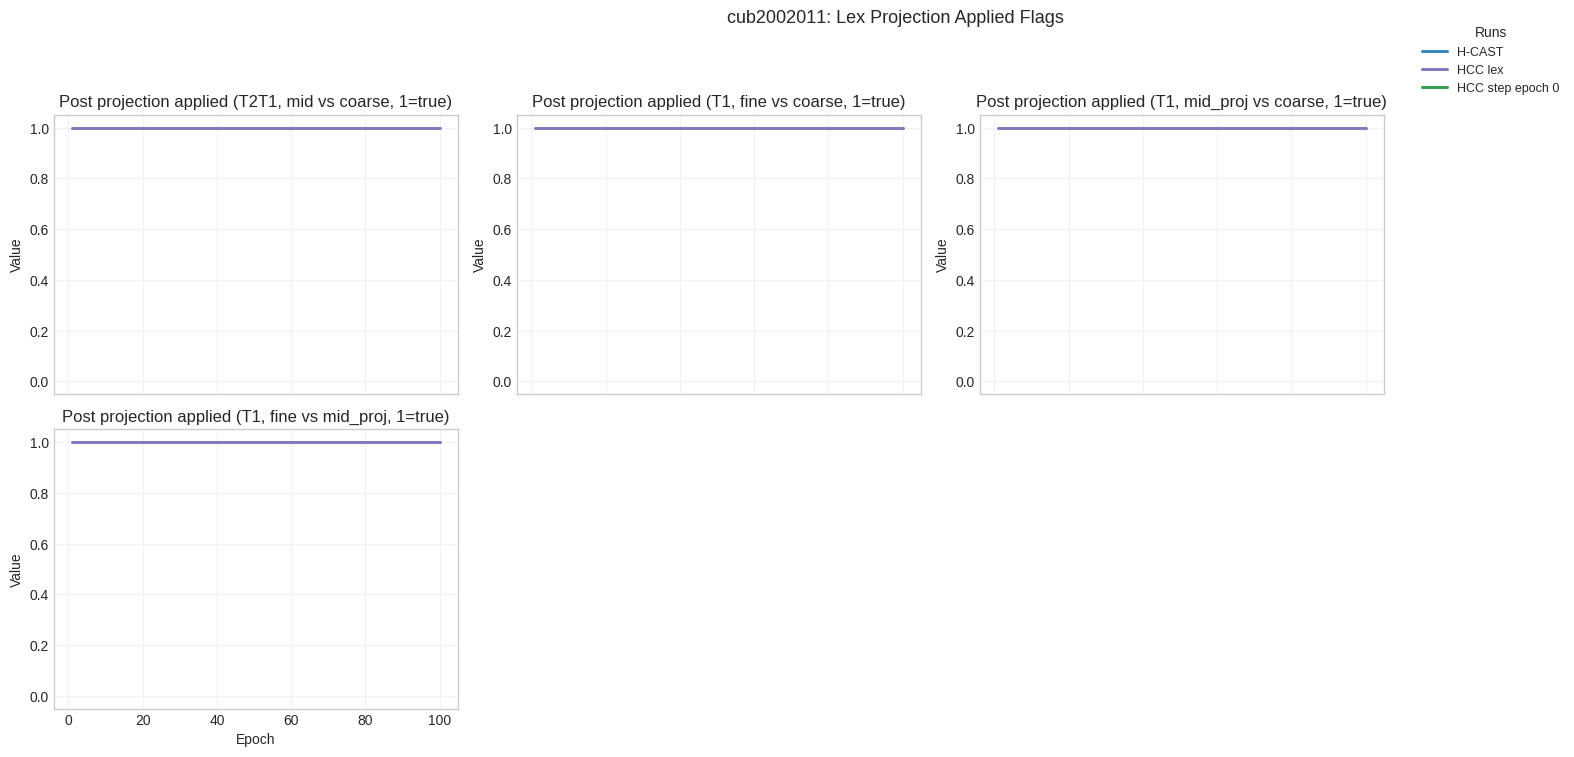

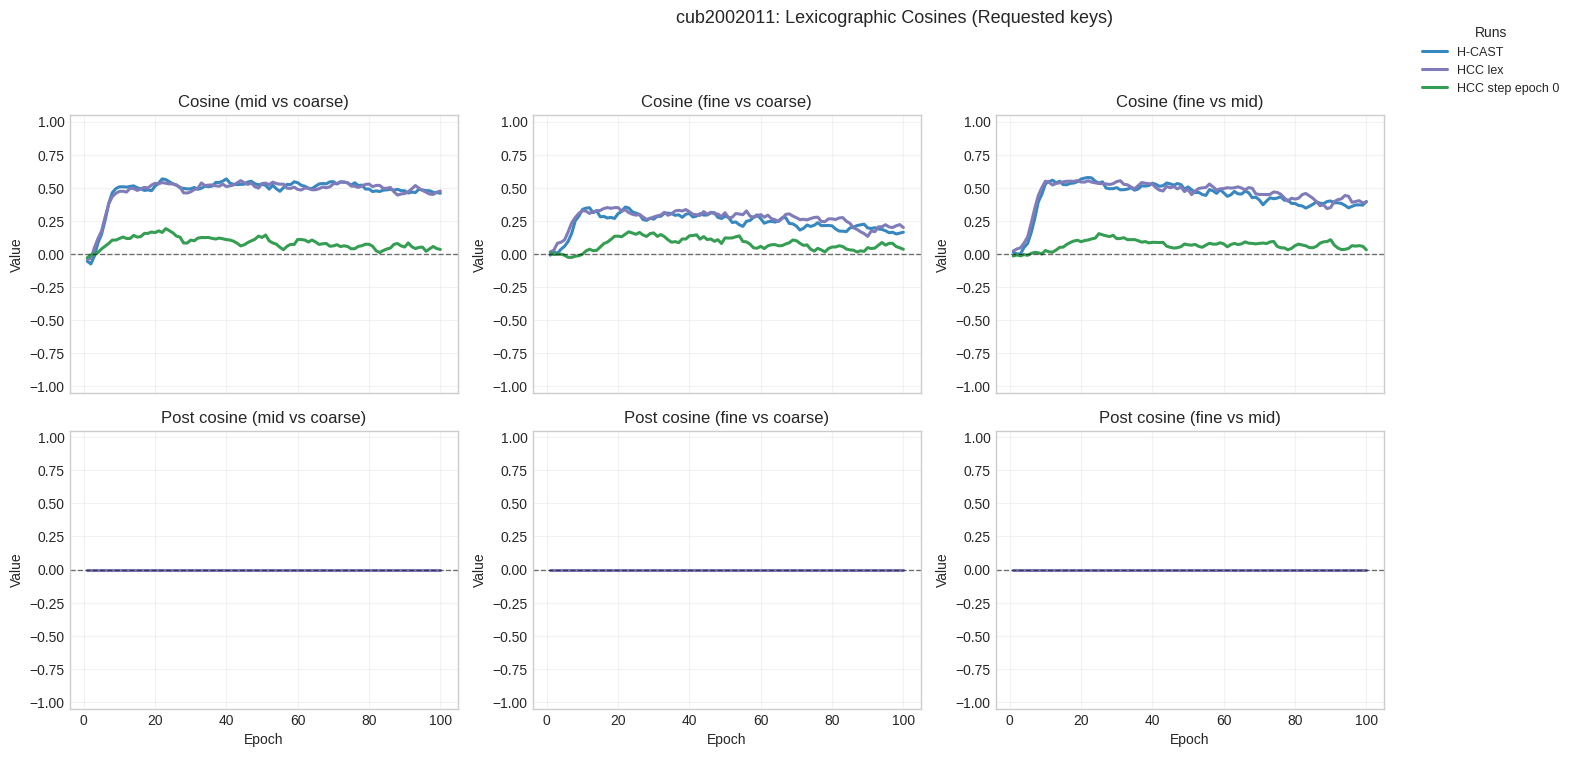

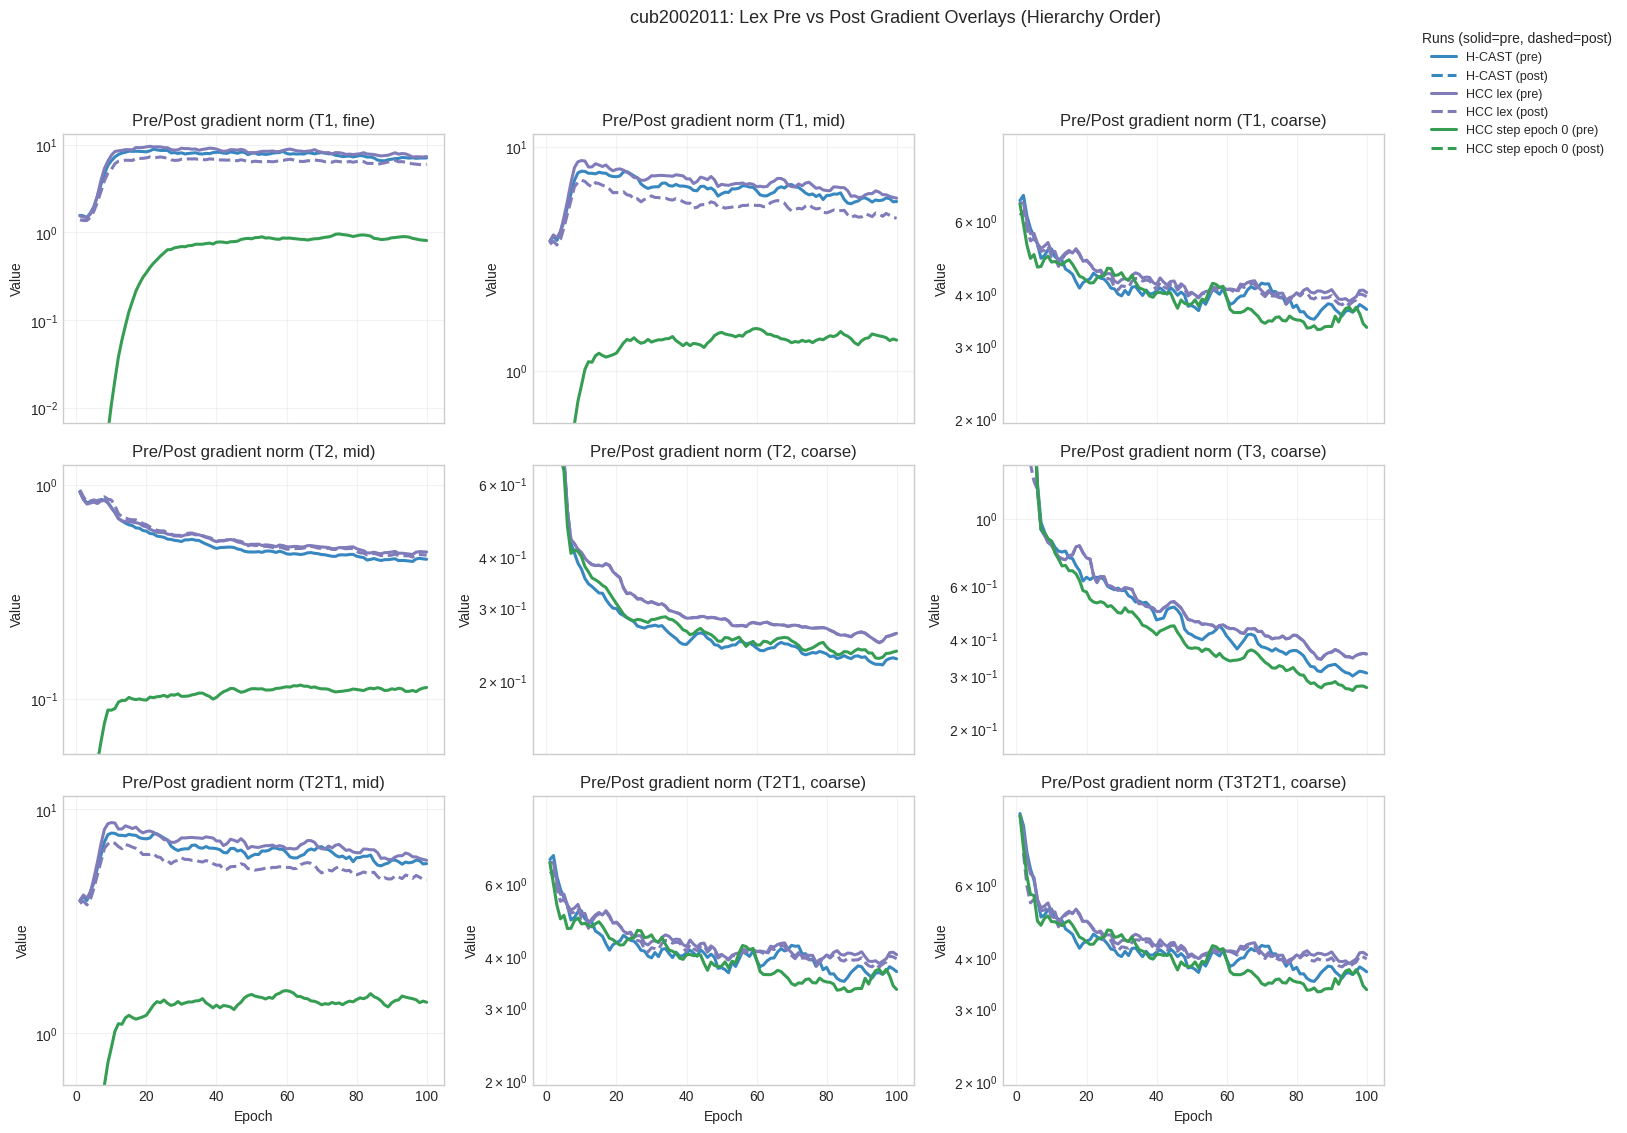

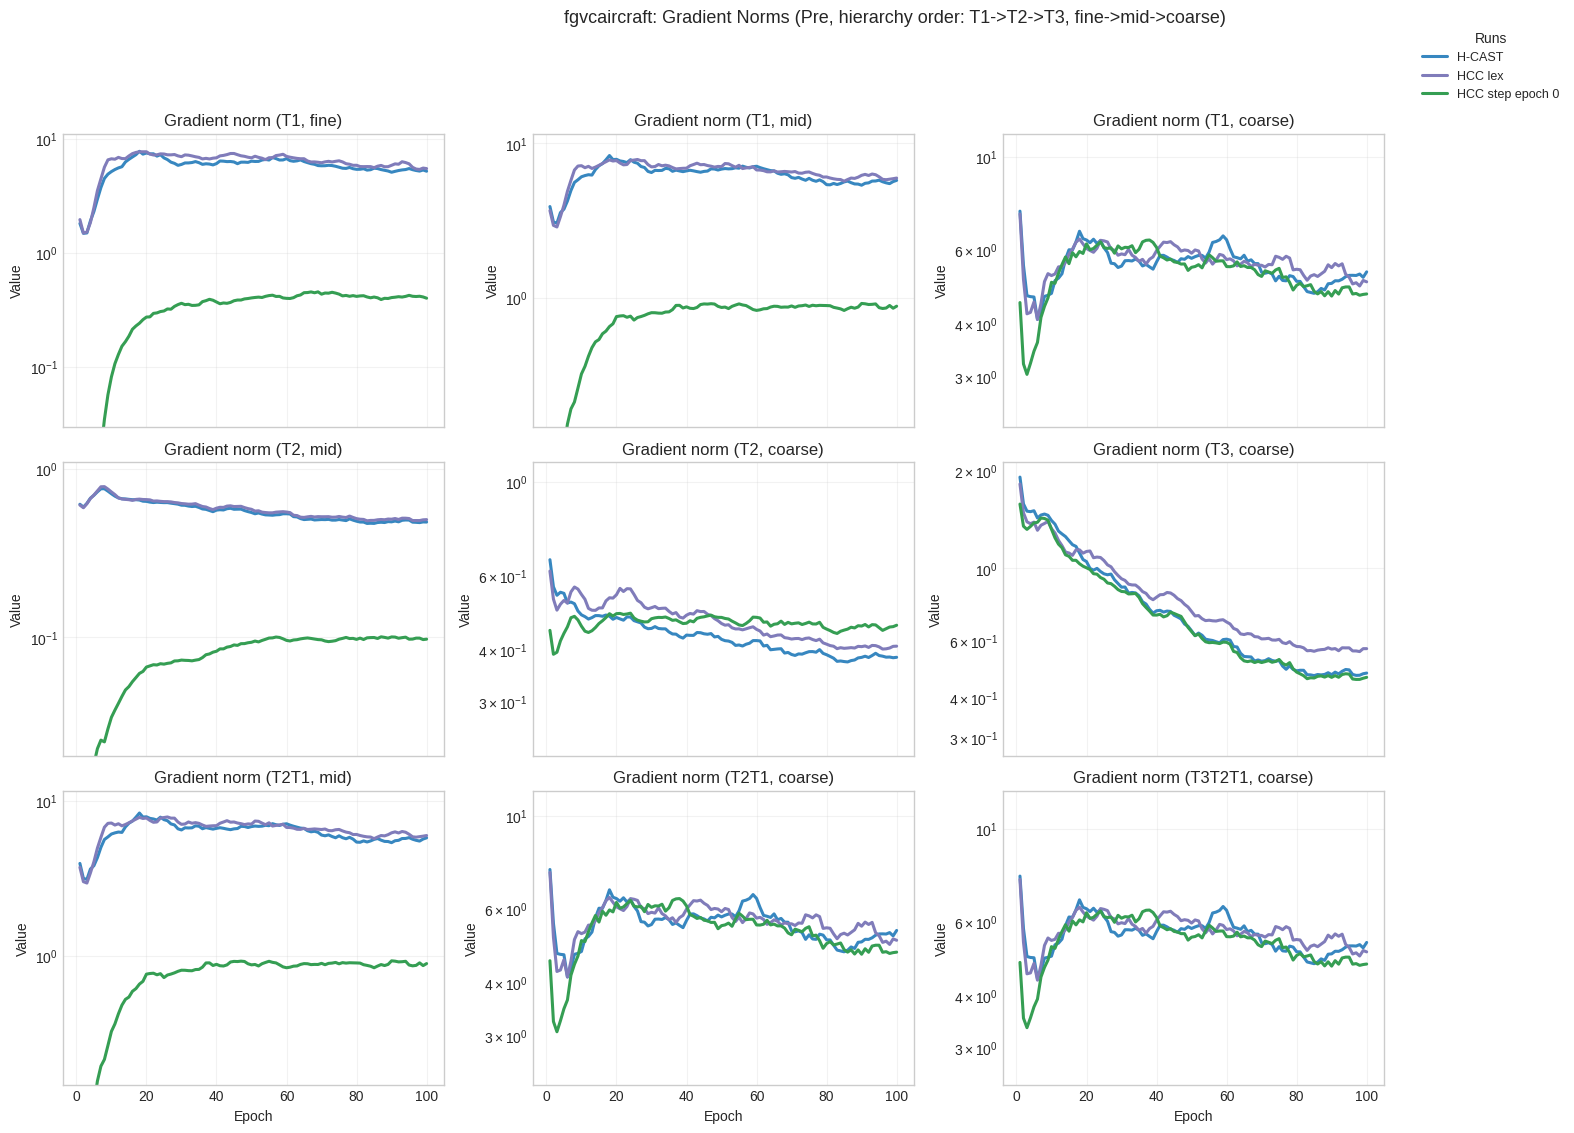

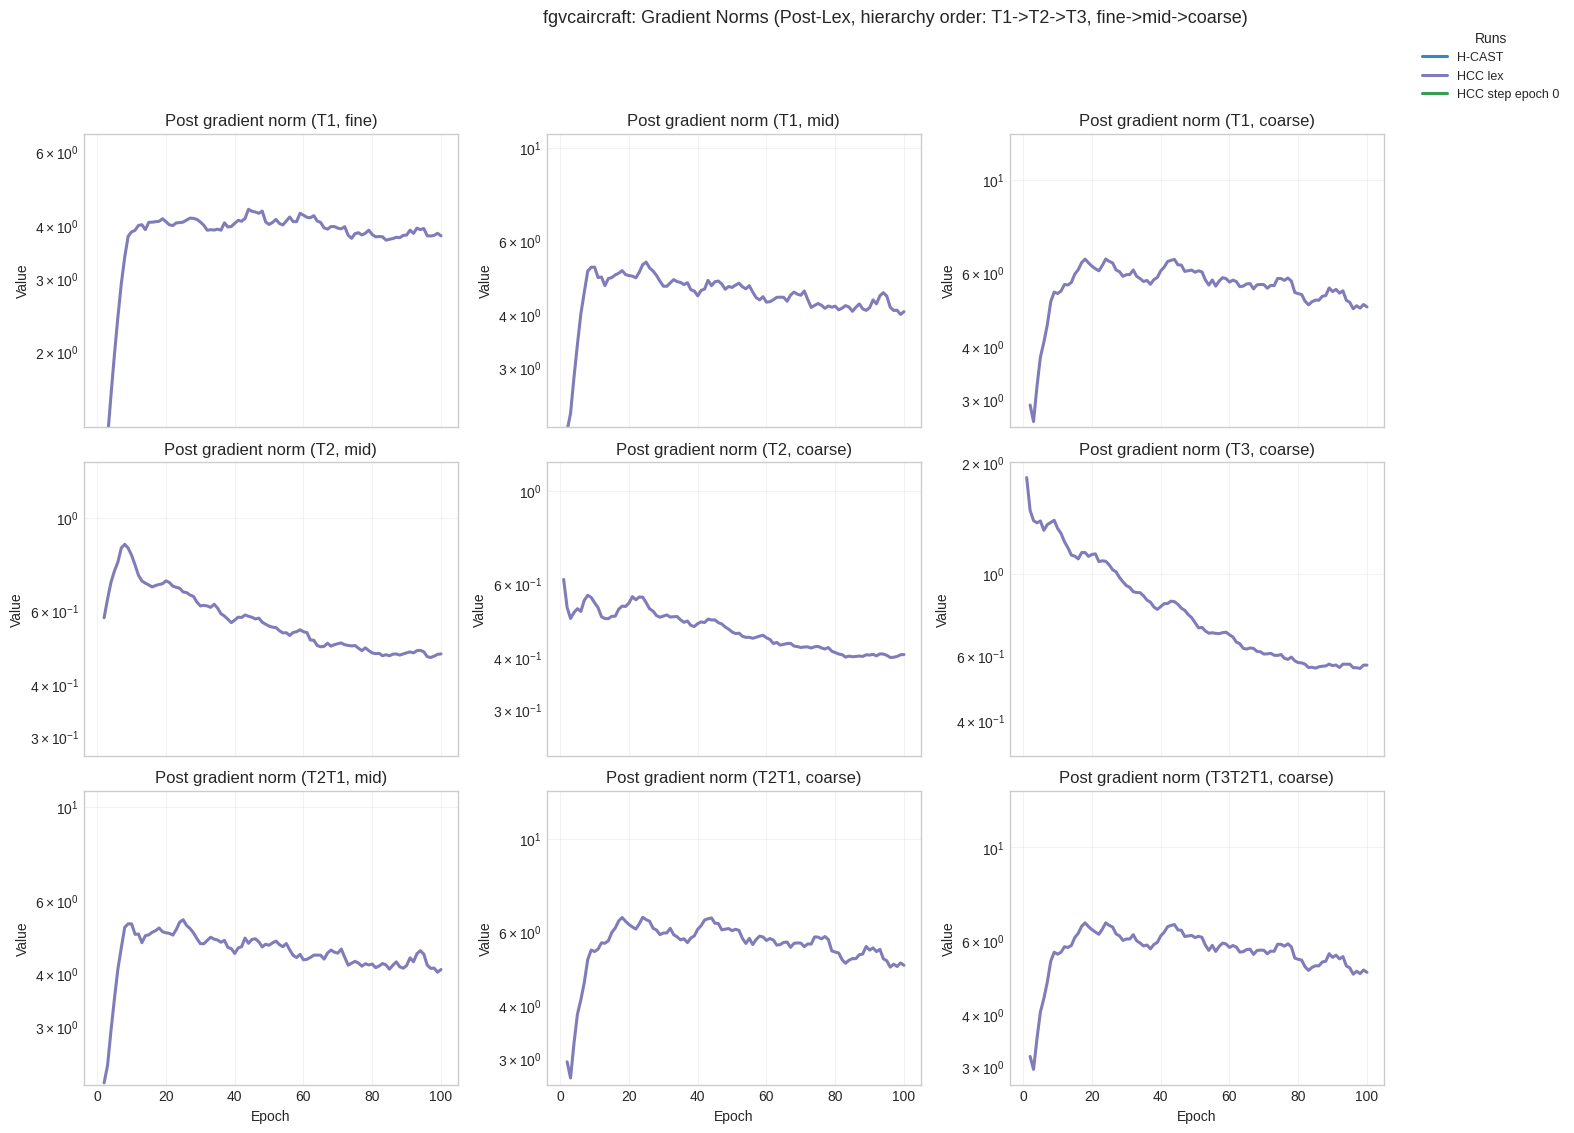

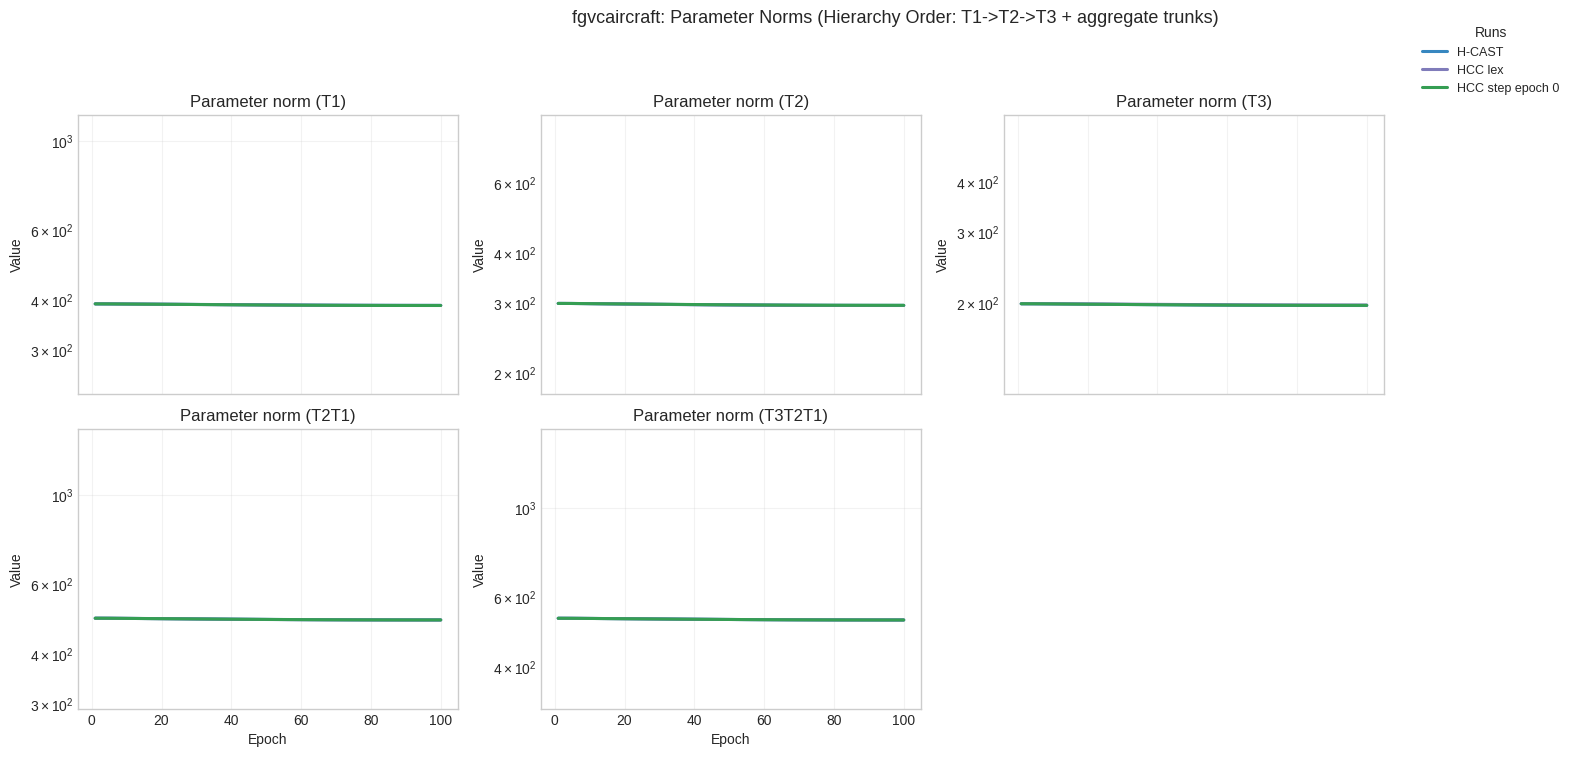

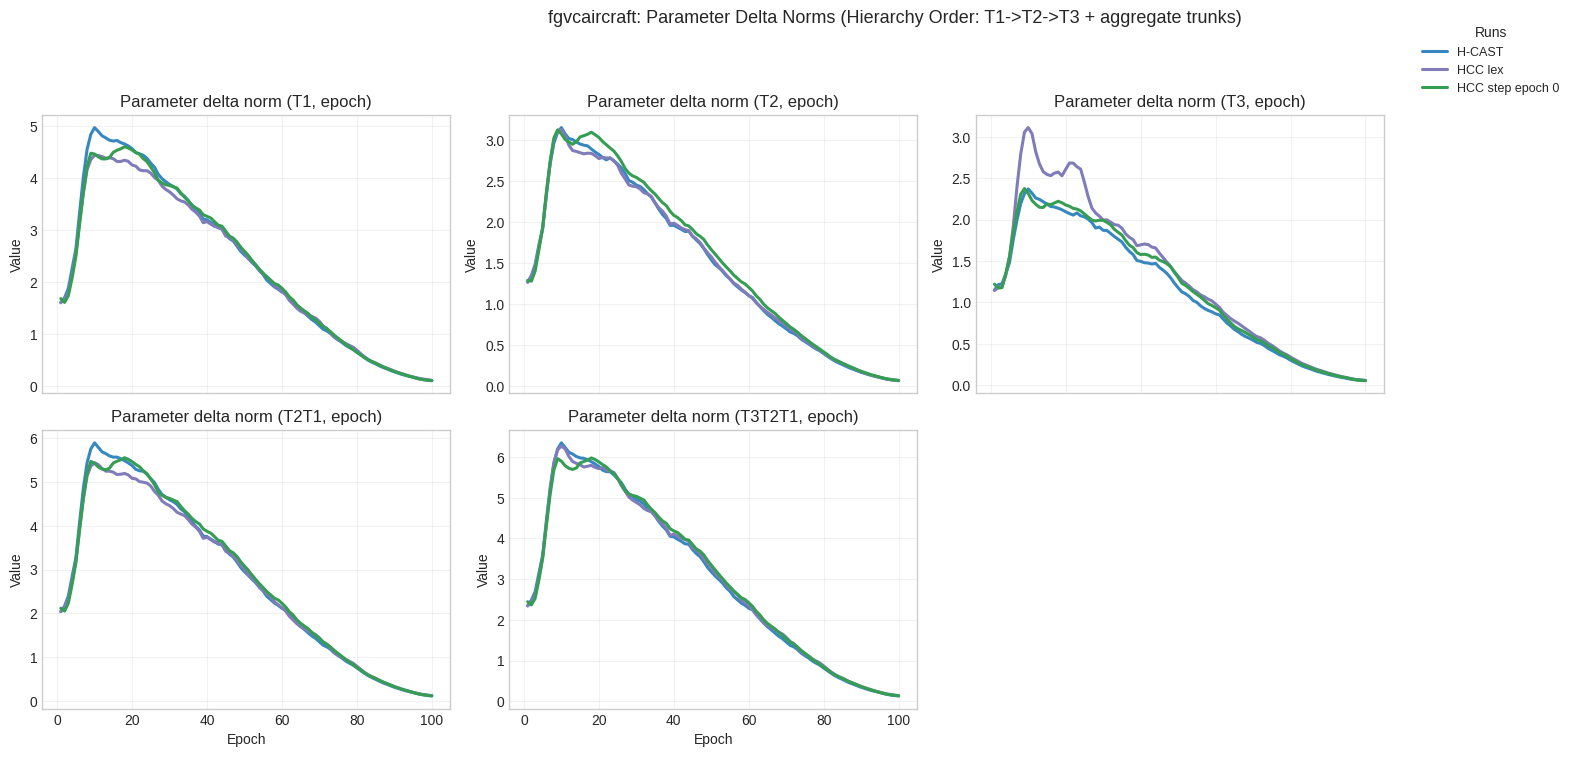

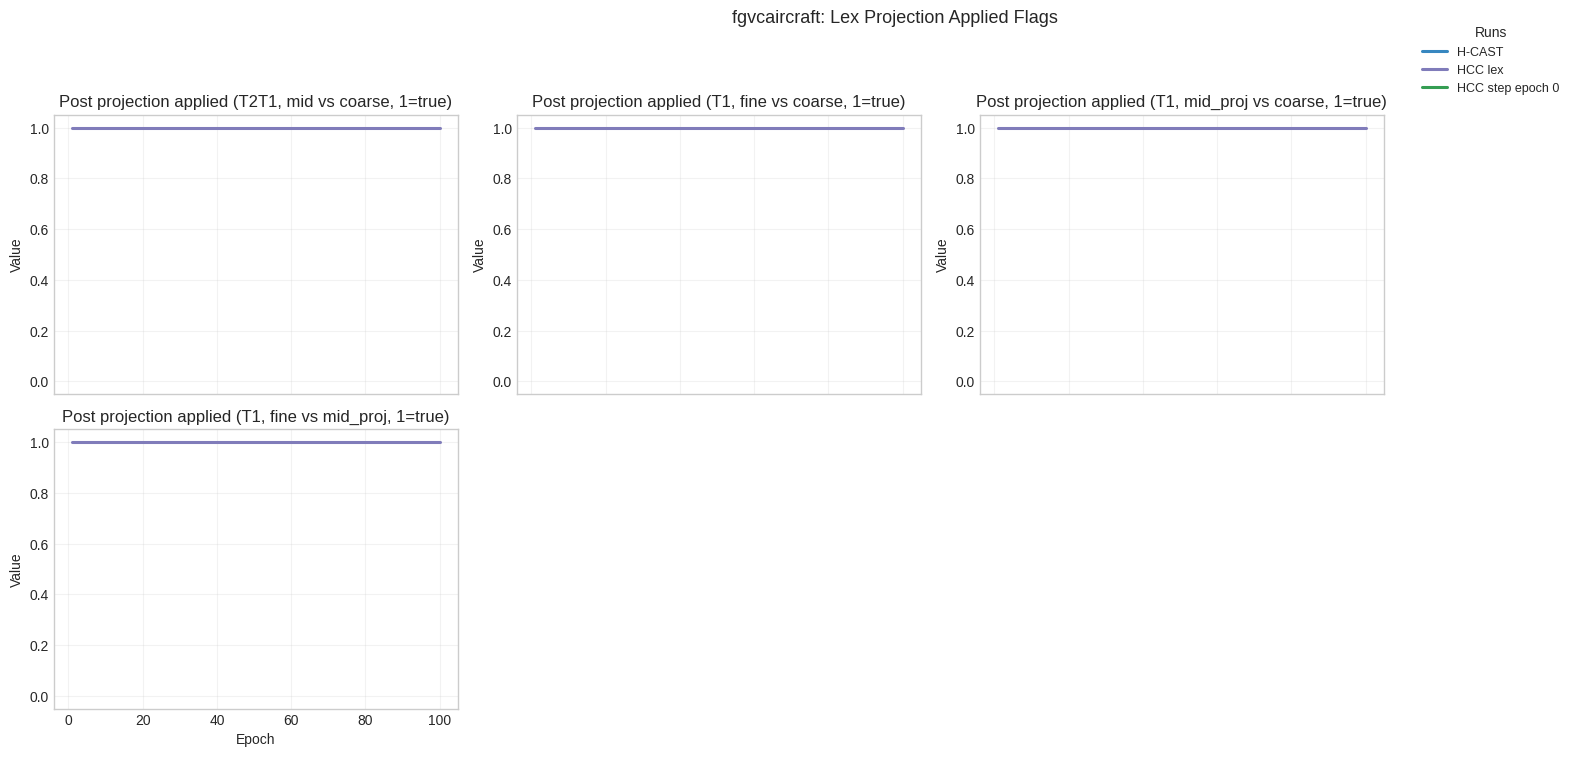

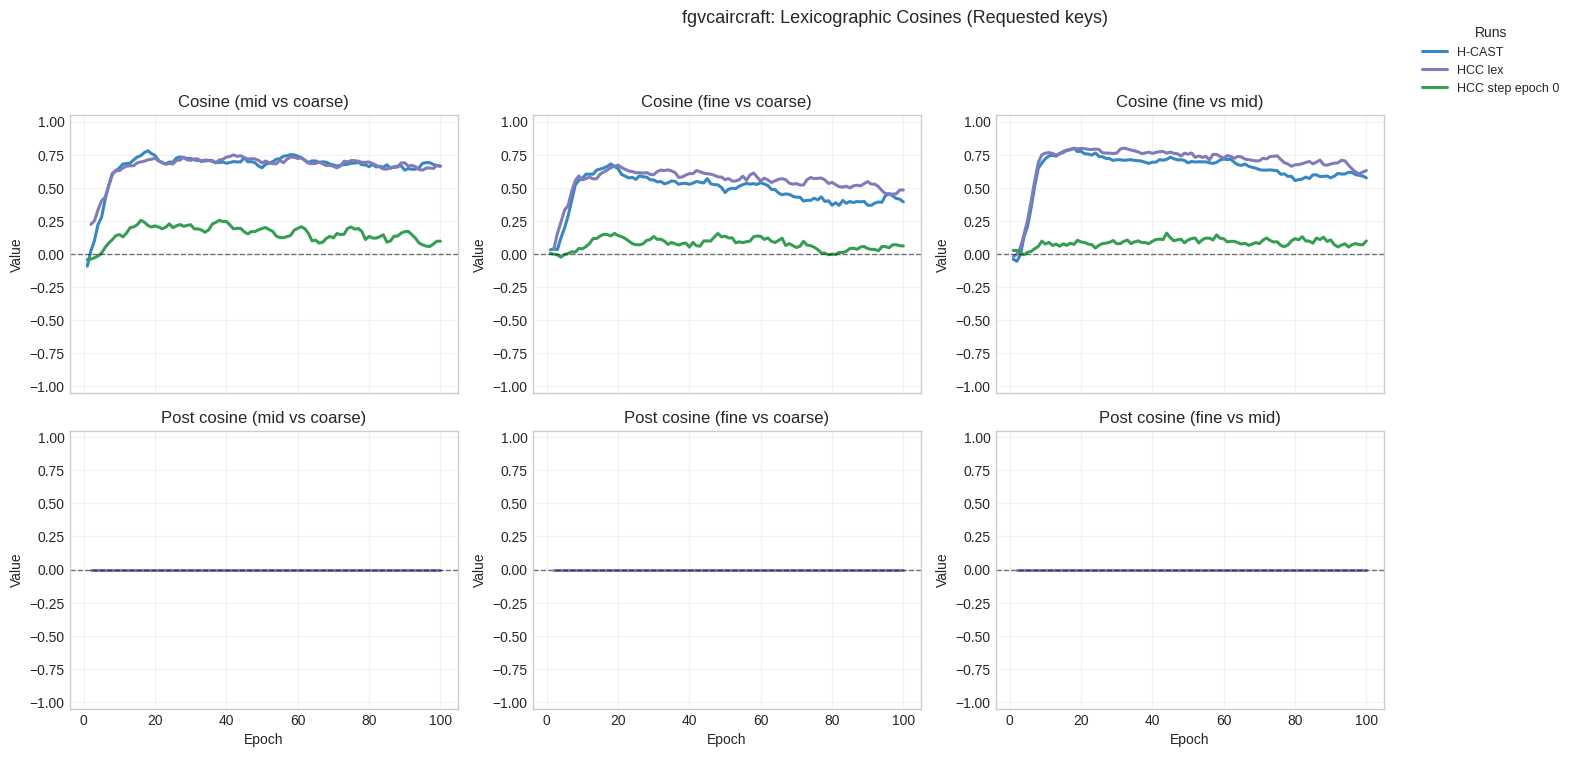

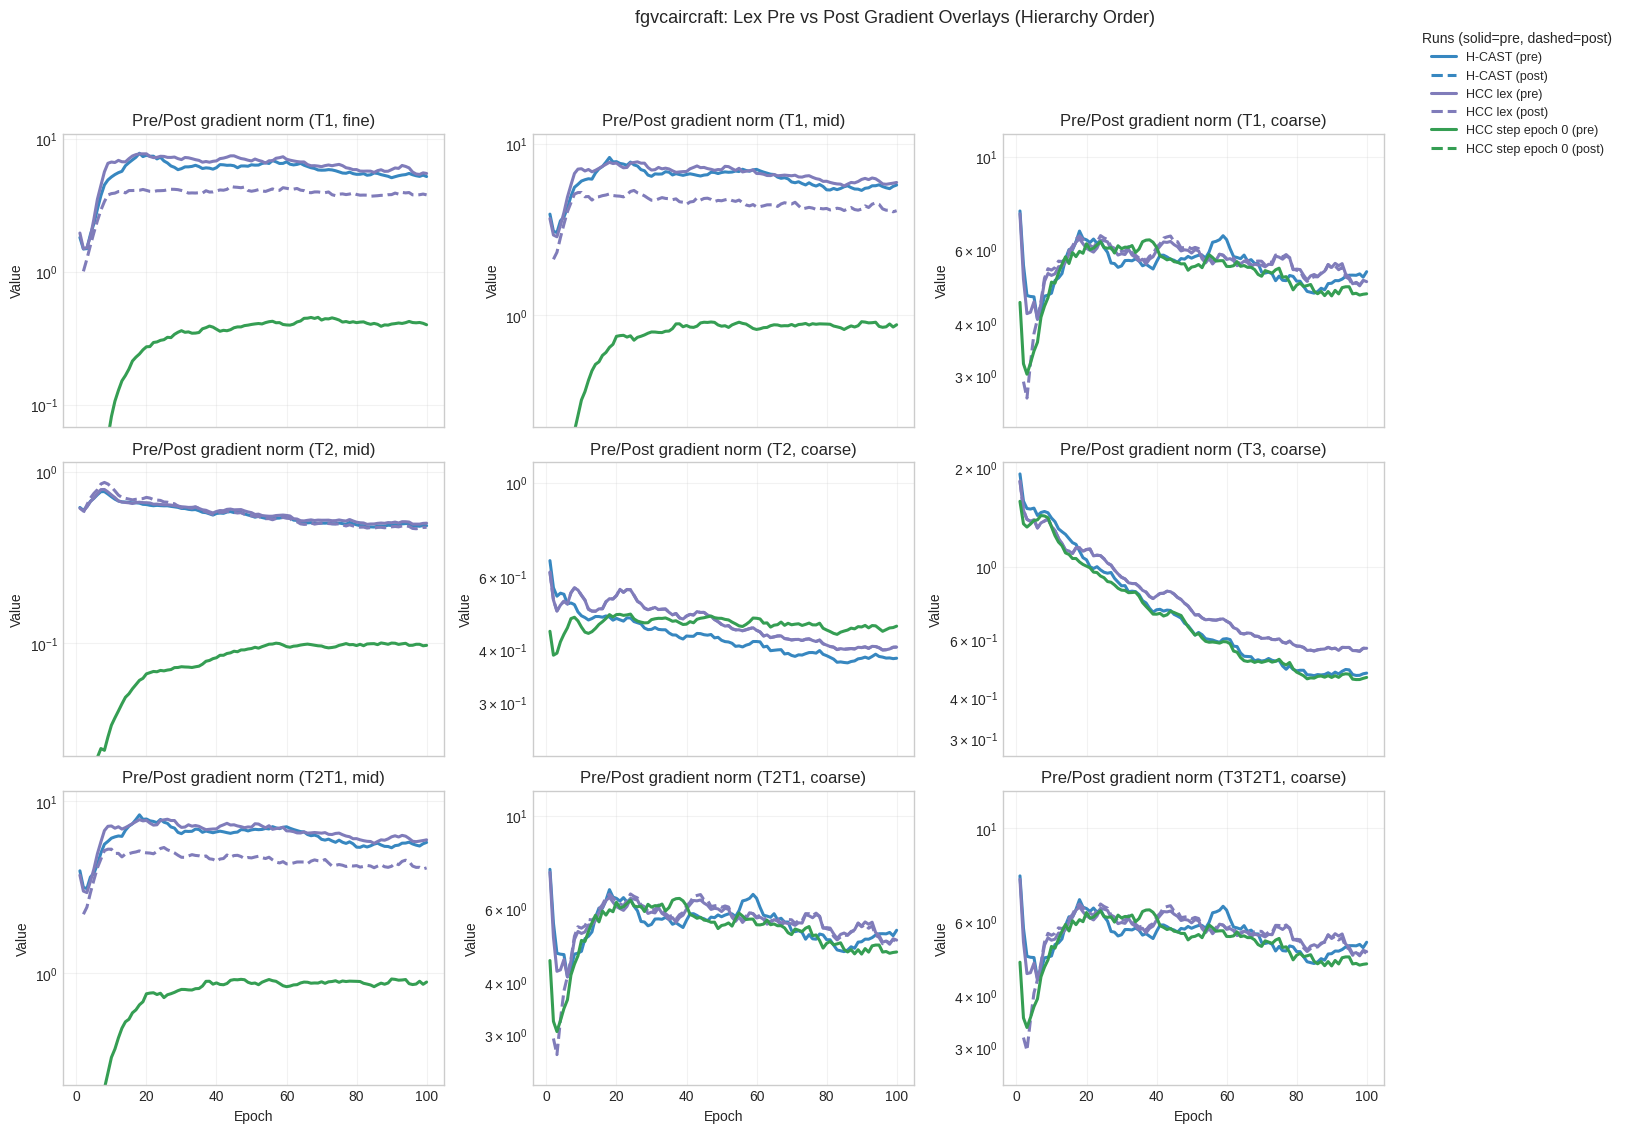

In [66]:
GRAD_SMOOTH_WINDOW = 5
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = True
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)


Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- If `grad_norm_t1_fine` collapses while `t1` coarse/mid stay high, fine supervision is not effectively reaching shared parameters.
- Negative cosine values indicate level conflict on the corresponding subset.
- `param_norm_*` is scale, `delta_param_norm_*` is per-epoch movement.
- In lex mode, projected cosines should move near 0 (orthogonality on the target mask).
- `post_projection_applied_* = 0` means the corresponding projection step was skipped for numerical safety.


## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

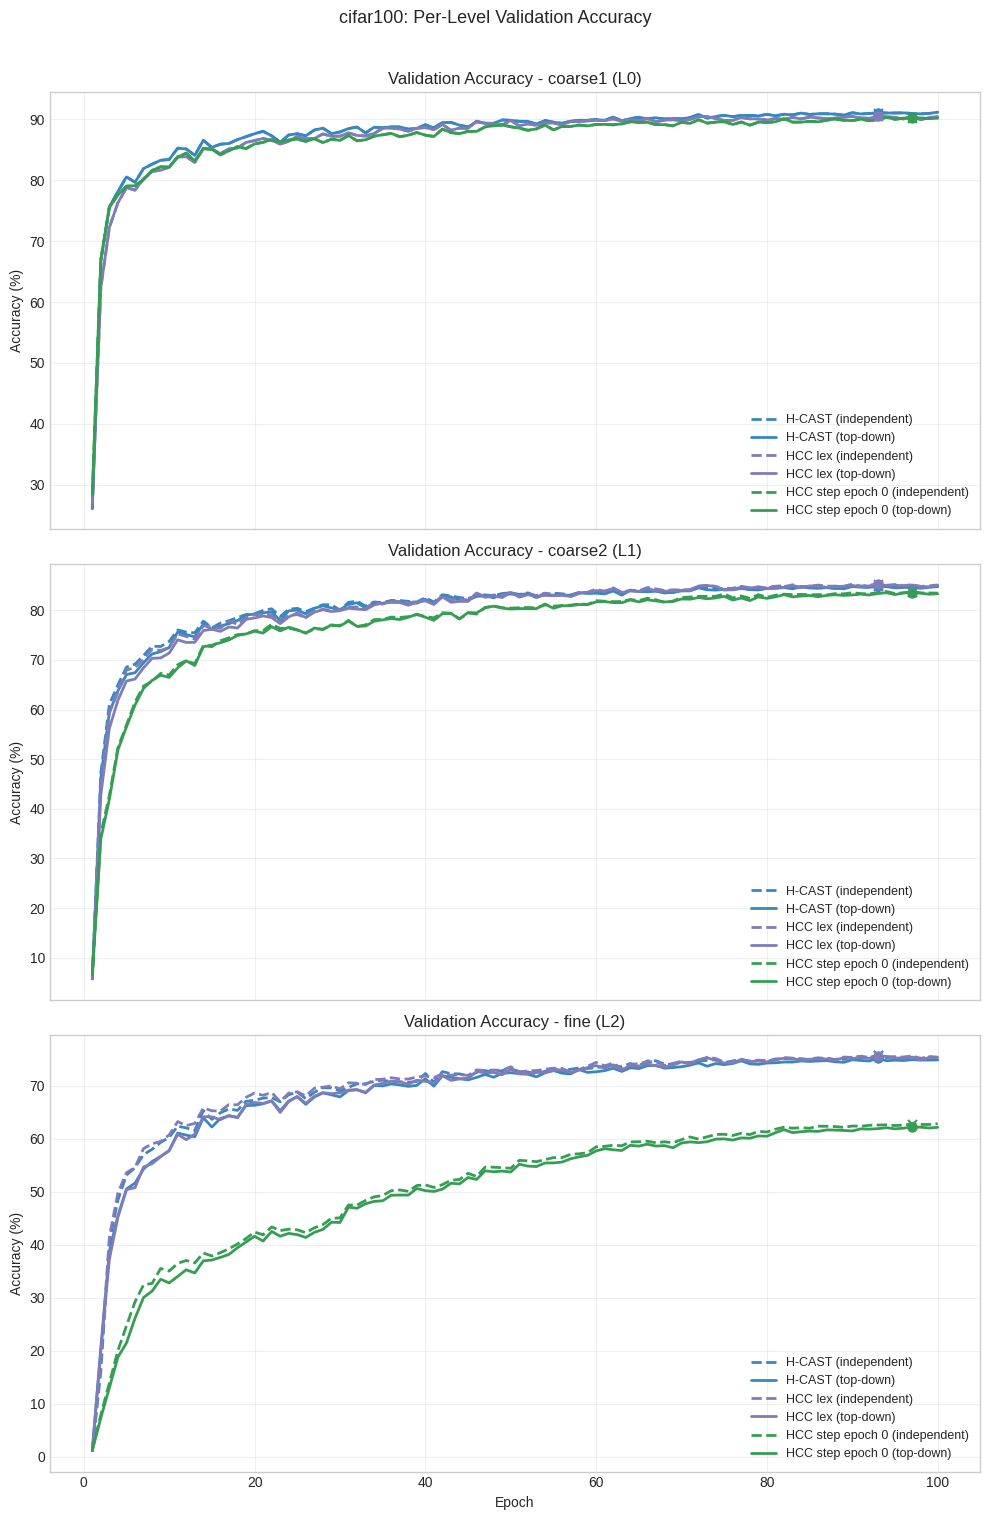

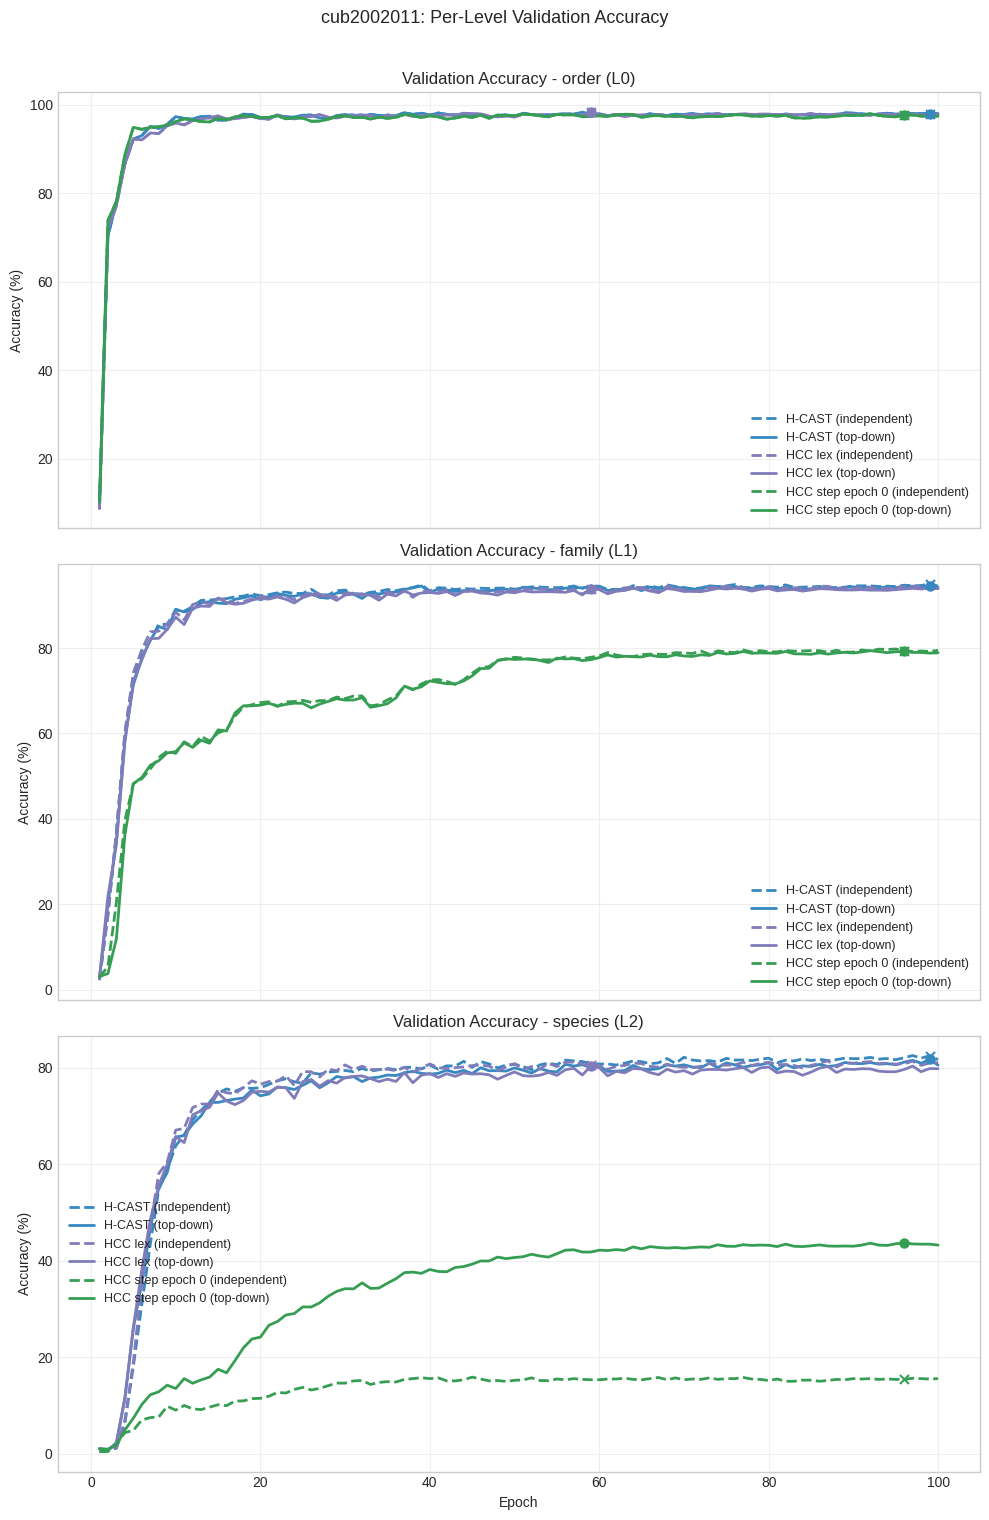

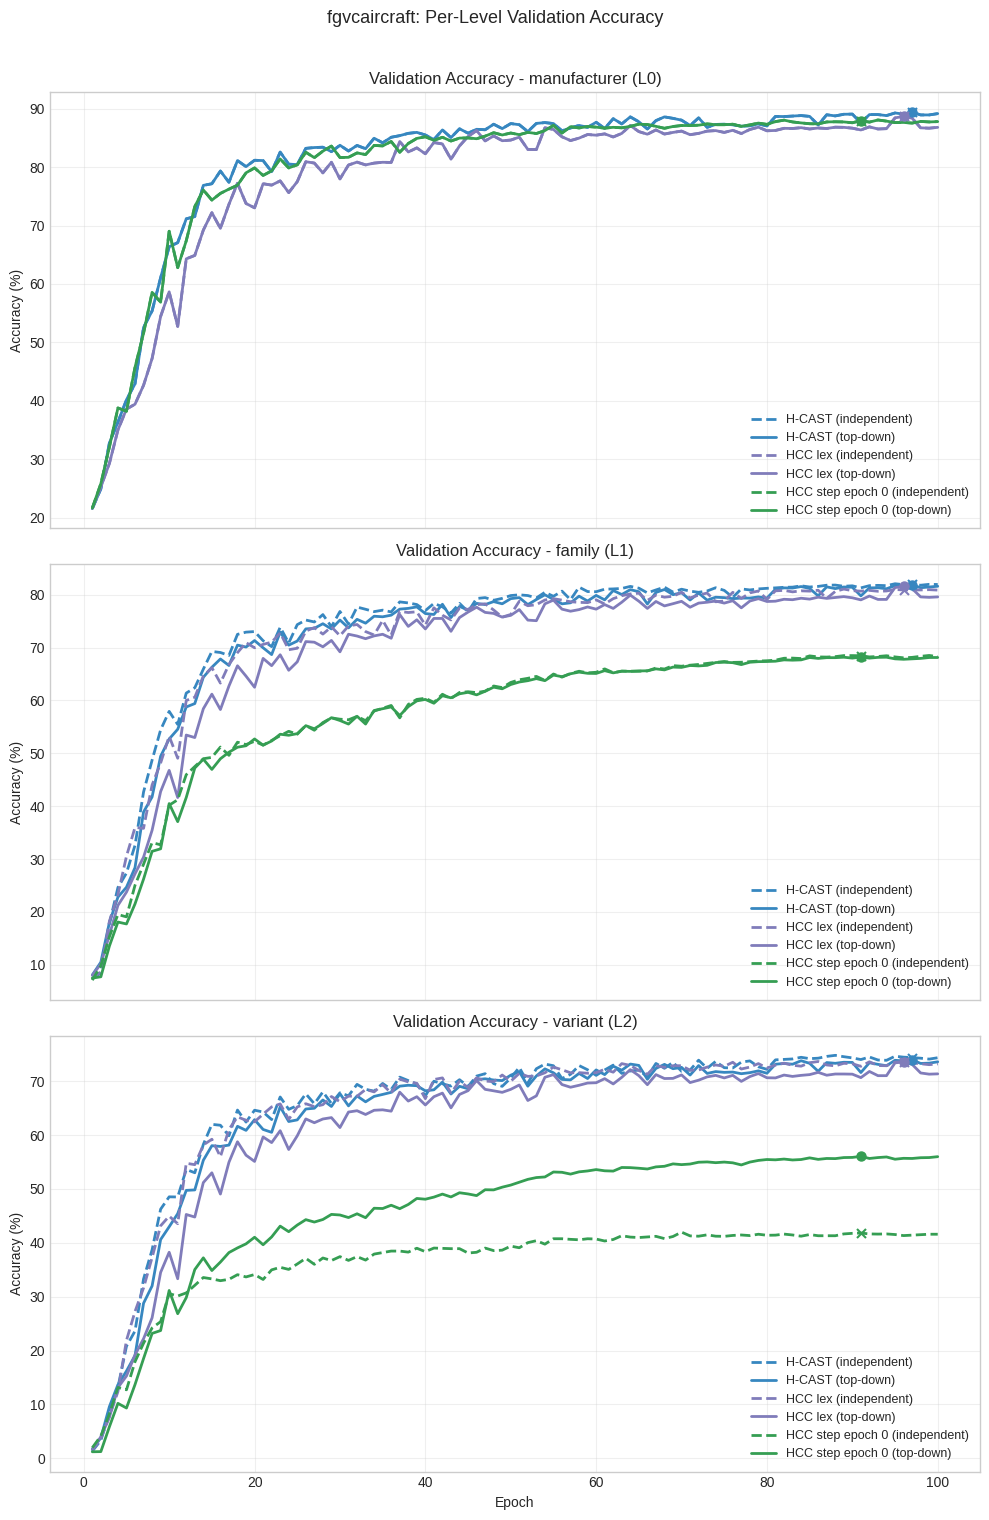

In [67]:
analysis.plot_per_level_validation_accuracy()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected runs and reports deltas versus the first run listed for that dataset.

In [68]:
analysis.show_final_test_tables()


### Dataset: `cifar100`
Baseline run: **H-CAST**

| Metric | H-CAST | HCC lex | HCC step epoch 0 |
|---|---:|---:|---:|
| FPA independent ↑ | 72.39% | **73.23% (+0.84 pp)** | 61.62% (-10.77 pp) |
| FPA top-down ↑ | 74.28% | **74.45% (+0.18 pp)** | 62.30% (-11.97 pp) |
| wAP independent ↑ | **77.63%** | 77.60% (-0.03 pp) | 67.77% (-9.86 pp) |
| wAP top-down ↑ | 76.91% | **77.00% (+0.09 pp)** | 67.26% (-9.65 pp) |
| TICE independent ↓ | 8.32% | 6.25% (-2.07 pp) | **4.32% (-4.00 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 1.059 | **1.045 (-0.013)** | 1.323 (+0.264) |
| AHD top-down ↓ | **1.011** | 1.016 (+0.005) | 1.295 (+0.284) |
| Acc independent coarse1 (L0) ↑ | **90.59%** | 90.38% (-0.21 pp) | 90.04% (-0.55 pp) |
| Acc top-down coarse1 (L0) ↑ | **90.59%** | 90.38% (-0.21 pp) | 90.04% (-0.55 pp) |
| Acc independent coarse2 (L1) ↑ | **84.59%** | 84.44% (-0.15 pp) | 82.81% (-1.78 pp) |
| Acc top-down coarse2 (L1) ↑ | **84.58%** | 84.38% (-0.21 pp) | 82.90% (-1.68 pp) |
| Acc independent fine (L2) ↑ | 75.20% | **75.21% (+0.01 pp)** | 62.98% (-12.22 pp) |
| Acc top-down fine (L2) ↑ | 74.28% | **74.45% (+0.18 pp)** | 62.30% (-11.97 pp) |

### Dataset: `cub2002011`
Baseline run: **H-CAST**

| Metric | H-CAST | HCC lex | HCC step epoch 0 |
|---|---:|---:|---:|
| FPA independent ↑ | **79.27%** | 78.04% (-1.23 pp) | 12.77% (-66.50 pp) |
| FPA top-down ↑ | **80.96%** | 80.20% (-0.76 pp) | 42.67% (-38.28 pp) |
| wAP independent ↑ | **84.17%** | 83.16% (-1.00 pp) | 28.54% (-55.62 pp) |
| wAP top-down ↑ | **83.73%** | 83.12% (-0.62 pp) | 51.02% (-32.72 pp) |
| TICE independent ↓ | **6.10%** | 6.75% (+0.65 pp) | 83.47% (+77.37 pp) |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | **0.587** | 0.621 (+0.033) | 2.210 (+1.623) |
| AHD top-down ↓ | **0.550** | 0.569 (+0.018) | 1.608 (+1.058) |
| Acc independent order (L0) ↑ | 98.08% | 97.94% (-0.14 pp) | **98.10% (+0.02 pp)** |
| Acc top-down order (L0) ↑ | 98.08% | 97.94% (-0.14 pp) | **98.10% (+0.02 pp)** |
| Acc independent family (L1) ↑ | **93.57%** | 93.30% (-0.27 pp) | 79.09% (-14.48 pp) |
| Acc top-down family (L1) ↑ | **93.44%** | 93.41% (-0.03 pp) | 78.82% (-14.62 pp) |
| Acc independent species (L2) ↑ | **81.48%** | 80.28% (-1.20 pp) | 14.42% (-67.06 pp) |
| Acc top-down species (L2) ↑ | **80.96%** | 80.20% (-0.76 pp) | 42.67% (-38.28 pp) |

### Dataset: `fgvcaircraft`
Baseline run: **H-CAST**

| Metric | H-CAST | HCC lex | HCC step epoch 0 |
|---|---:|---:|---:|
| FPA independent ↑ | 69.41% | **69.92% (+0.51 pp)** | 37.57% (-31.84 pp) |
| FPA top-down ↑ | 72.31% | **72.73% (+0.42 pp)** | 54.20% (-18.11 pp) |
| wAP independent ↑ | **78.62%** | 78.20% (-0.42 pp) | 55.76% (-22.86 pp) |
| wAP top-down ↑ | 77.23% | **77.72% (+0.50 pp)** | 62.89% (-14.34 pp) |
| TICE independent ↓ | 13.32% | **12.62% (-0.70 pp)** | 46.76% (+33.44 pp) |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 1.282 | **1.259 (-0.024)** | 2.237 (+0.955) |
| AHD top-down ↓ | 1.208 | **1.178 (-0.030)** | 1.895 (+0.687) |
| Acc independent manufacturer (L0) ↑ | 87.38% | **87.83% (+0.45 pp)** | 85.37% (-2.01 pp) |
| Acc top-down manufacturer (L0) ↑ | 87.38% | **87.83% (+0.45 pp)** | 85.37% (-2.01 pp) |
| Acc independent family (L1) ↑ | **81.44%** | 80.60% (-0.84 pp) | 65.89% (-15.55 pp) |
| Acc top-down family (L1) ↑ | 79.90% | **80.52% (+0.62 pp)** | 65.67% (-14.23 pp) |
| Acc independent variant (L2) ↑ | **74.02%** | 73.63% (-0.39 pp) | 39.78% (-34.24 pp) |
| Acc top-down variant (L2) ↑ | 72.31% | **72.73% (+0.42 pp)** | 54.20% (-18.11 pp) |

Interpretation note:
- Metrics are rows and runs are columns.
- Goal arrows are in metric names: `↑` means maximize, `↓` means minimize.
- Non-baseline run cells show `value (delta vs baseline)`.
- Bold cells mark the best run for each metric in the dataset table.
- Delta is computed as `run - baseline`.
